<div style="text-align: right;">
  <img src="Logo_UNSAM.png" width="250">
</div>

Analisis y Procesamiento de Señales

# TS2: Modelizando un ADC

## Estudiante: Mercedes López Gil Dillon

En el siguiente trabajo, buscamos cuantizar una señal con ruido incorrelado, analizando la relacion entre la señal original y la cuantizada a medida que variamos los parámetros de entrada, con el objetivo de poder entender cómo se relacionan distintas variables como kn y B al resultado que obtenemos.

## Ejercicio 1

El objetivo de este ejercicio es generar una señal con los siguientes parámetros:
- fs = 1000Hz
- ±VF=2 V
- B = 4 bits
- kn = 1
  
Generando a partir de esta señal los siguientes gráficos:
- Un grafico comparativo de amplitud vs tiempo de la señal pura, la señal con ruido y la señal cuantizada.
- Un grafico comparativo de densidad de potencia en dB vs frecuencia de la señal pura, la señal con ruido y la señal cuantizada, utilizando además el piso analógico y digital como guías.
- Un histograma del ruido de cuantización.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1/fs
    tt = np.arange(0, nn) * ts 
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx

def mi_funcion_sen_ruido(vmax, dc, ff, ph, nn, fs, snr, pr):
    ts = 1/fs
    tt = np.arange(0, nn) * ts
    desvio = np.sqrt(pr)
    r = np.random.normal(0, desvio, len(tt)) 
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    xx1 = xx + r 
    return tt, xx1

***Primer gráfico***

Defino mis variables:

In [4]:
B = 4  # bits
Vfs = 2  # Volts

qq = ( Vfs) / (2**B) 
Pq = qq**2 / 12

A = np.sqrt(2)
dc = 0
fs = 1000
Ts= 1/fs
fase = 0
muestras = 1000
f0 = fs/muestras
Ps = (A**2)/ 2 

kn = 1

pr = kn * Pq 

snr = Ps / pr

Llamo y grafico mis funciones.

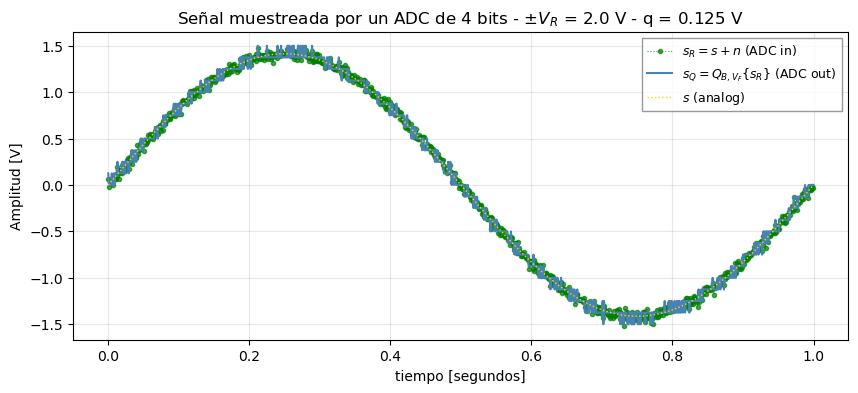

In [12]:
tt1, xx1 = mi_funcion_sen_ruido(A, dc, f0, fase, muestras, fs, snr, pr)
tt, xx = mi_funcion_sen(A, dc, f0, fase, muestras, fs)


Sr = xx1

sq = np.round(Sr / qq) * qq

plt.figure(figsize=(10, 4))
plt.plot(tt1, Sr, color='green', linewidth=0.8, linestyle=':', marker ='o', markersize=3, alpha=0.7, label=r'$s_R = s + n$ (ADC in)')
plt.plot(tt1, sq, color='steelblue', linewidth=1.5, linestyle='-', label=r'$s_Q = Q_{B,V_F}\{s_R\}$ (ADC out)')
plt.plot(tt, xx, color='gold', linewidth=1, linestyle=':', label=r'$s$ (analog)')
plt.title(f"Señal muestreada por un ADC de {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V")
plt.xlabel("tiempo [segundos]")
plt.ylabel("Amplitud [V]")
plt.grid(True, alpha=0.3)
plt.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=9)
plt.show()

***Segundo gráfico***

Ya teniendo nuestra señal cuantizada, buscamos observar su espectro en dB en función de la frecuencia. Esto nos permite ver gráficamente el nivel de ruido analógico y digital con el que estamos trabajando, lo cual está directamente relacionado con la calidad de la señal que tenemos.

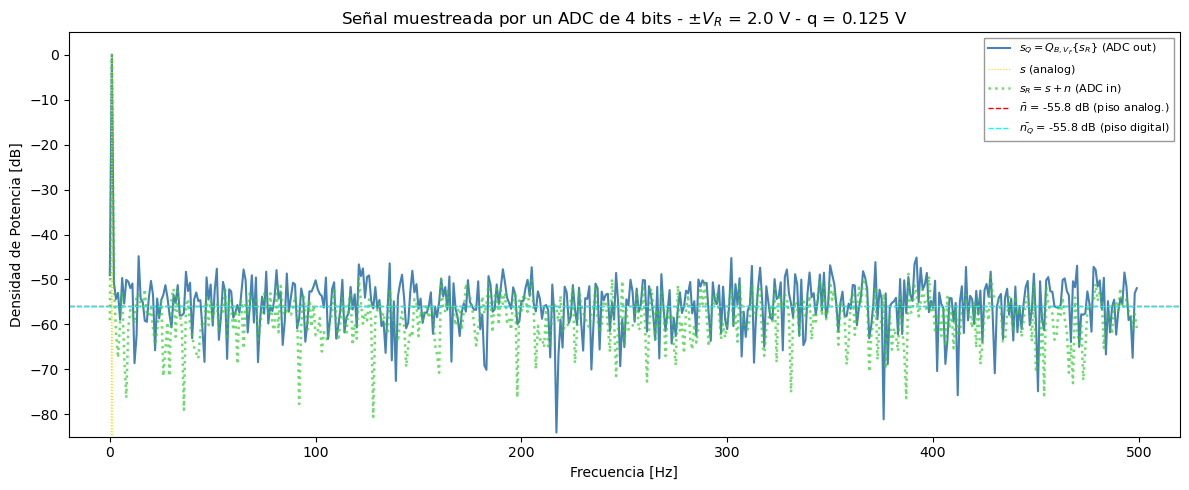

In [18]:
EspectroSr = np.fft.fft(Sr)/muestras
Mod_EspSr = 2 * (np.abs(EspectroSr))**2 

EspectroSq = np.fft.fft(sq)/muestras
Mod_EspSq = 2 * (np.abs(EspectroSq))**2 

EspectroXX = np.fft.fft(xx)/muestras
Mod_EspXX = 2 * (np.abs(EspectroXX))**2 

Sr_db = 10 * np.log10(Mod_EspSr) 
sq_db = 10 * np.log10(Mod_EspSq) 
xx_db = 10 * np.log10(Mod_EspXX)

Frec = np.fft.fftfreq(muestras, Ts)

piso_analog = 10 * np.log10(pr / (fs/2))      # densidad espectral del ruido aditivo (potencia/ancho de banda)
piso_digital = 10 * np.log10(Pq / (fs/2))     # densidad espectral del ruido de cuantización

mitad = muestras // 2
Frec_pos = Frec[:mitad]

# Espectros solo frecuencias positivas
Sr_db_pos = Sr_db[:mitad]
sq_db_pos = sq_db[:mitad]
xx_db_pos = xx_db[:mitad]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(Frec_pos, sq_db_pos, color='steelblue', linewidth=1.5, linestyle='-',
        label=r'$s_Q = Q_{B,V_F}\{s_R\}$ (ADC out)')
ax.plot(Frec_pos, xx_db_pos, color='gold', linewidth=0.8, linestyle=':',
        label=r'$s$ (analog)')
ax.plot(Frec_pos, Sr_db_pos, color='limegreen', linewidth=1.8, linestyle=':',
        markersize=2, alpha=0.7, label=r'$s_R = s + n$ (ADC in)')
ax.axhline(piso_analog,  color='red',  linestyle='--', linewidth=1,
           label=fr'$\bar{{n}}$ = {piso_analog:.1f} dB (piso analog.)')
ax.axhline(piso_digital, color='cyan', linestyle='--', linewidth=1,
           label=fr'$\bar{{n_Q}}$ = {piso_digital:.1f} dB (piso digital)')

ax.set_title(f"Señal muestreada por un ADC de {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylim([-85, 5]) 
ax.set_ylabel("Densidad de Potencia [dB]")
ax.set_xlim([-20, fs/2 + 20])
ax.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=8)

plt.tight_layout()
plt.show()

Para realizar este gráfico, unicamente se utilizaron las frecuencias positivas (entre 0 y nyquist). Esto se hizo ya que la información luego de nyquist es un espejo conjugado de las otras, por lo que no me aportan información adicional. Además, al utilizar también las negativas, al llegar a nyquist vuelve a mapear las frecuencias negativas, generando un trazo diagonal en el gráfico.

Podemos observar en el gráfico como ambas señales (tanto sq como sr) son muy parecidas, lo cual concuerda con los pisos de ruido calculados (puesto que el piso de ruido analógico y digital son iguales). Esto tiene sentido, ya que en este caso estamos utilizando un kn = 1, lo cual provoca que nuestra potencia de ruido y de cuantización sean exactamente iguales.

***Tercer gráfico***

Para el último gráfico de este primer ejercicio, buscamos generar un histograma de el error de cuantización, donde utilizaremos las líneas guía para corroborar los valores del error de cuantización.

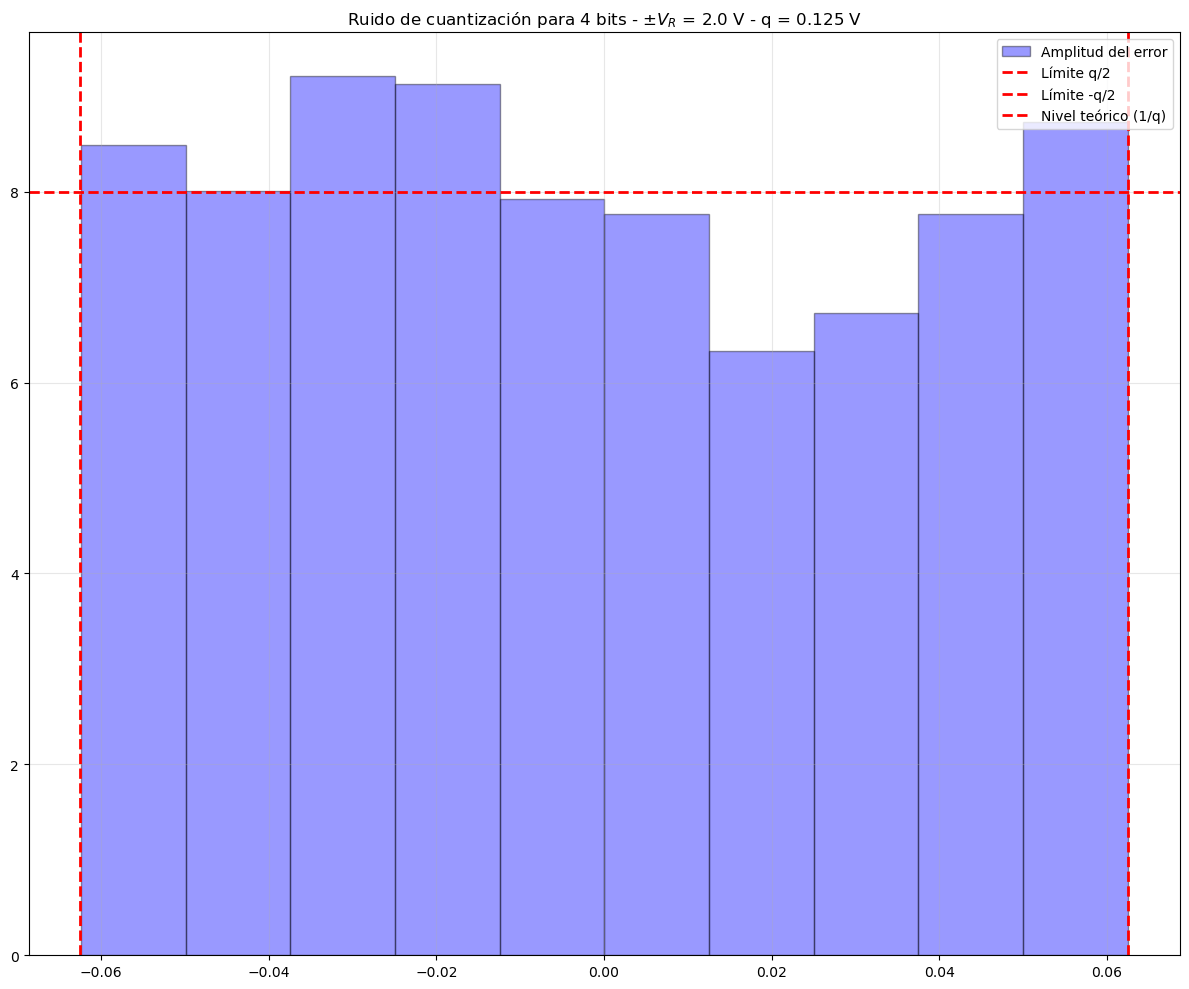

In [21]:
Eq = sq - Sr

plt.figure(figsize=(12, 10))
plt.subplot(1, 1, 1)
plt.hist(Eq, bins= 10, density=True, color='blue', alpha=0.4, edgecolor='black', label='Amplitud del error')

# Líneas guía teóricas: el error de cuantización debe vivir entre -q/2 y q/2
plt.axvline(x=qq/2, color='red', linestyle='--', linewidth=2, label='Límite q/2')
plt.axvline(x=-qq/2, color='red', linestyle='--', linewidth=2, label='Límite -q/2')

# Valor teórico de la PDF uniforme: 1/q
plt.axhline(y=1/qq, color='red', linestyle='--', linewidth=2, label='Nivel teórico (1/q)')

plt.title(f'Ruido de cuantización para {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Podemos observar como el histograma se mantiene cercano a los valores teóricos esperados, con una fluctuación bastante baja. 

## Ejercicio 2

En este ejercicio, buscamos probar distintas combinaciones de los valores de B y kn, observado los cambios en los resultados para poder sacar conclusiones en base a estos.

### Primera combinacion: kn = 1/10, B = 4

In [120]:
B = 4  # bits
Vfs = 2  # Volts

qq = ( Vfs) / (2**B) 
Pq = qq**2 / 12

A = np.sqrt(2)
dc = 0
fs = 1000
Ts= 1/fs
fase = 0
muestras = 1000
f0 = fs/muestras
Ps = (A**2)/ 2 

kn = 1/10

pr = kn * Pq 

snr = Ps / pr

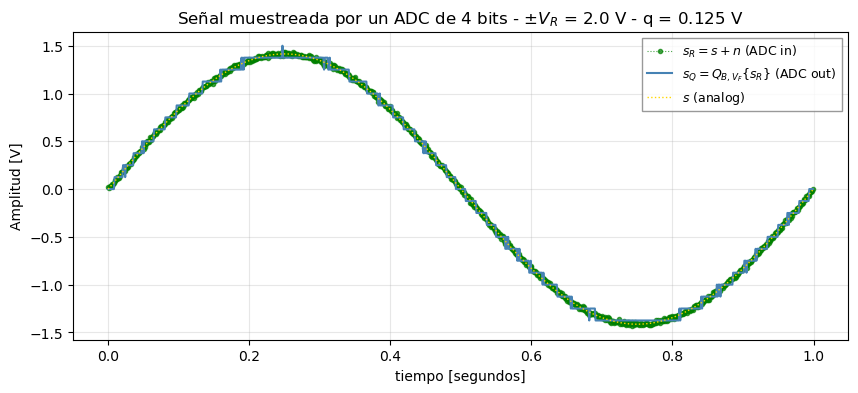

In [121]:
tt1, xx1 = mi_funcion_sen_ruido(A, dc, f0, fase, muestras, fs, snr, pr)
tt, xx = mi_funcion_sen(A, dc, f0, fase, muestras, fs)


Sr = xx1

sq = np.round(Sr / qq) * qq

plt.figure(figsize=(10, 4))
plt.plot(tt1, Sr, color='green', linewidth=0.8, linestyle=':', marker ='o', markersize=3, alpha=0.7, label=r'$s_R = s + n$ (ADC in)')
plt.plot(tt1, sq, color='steelblue', linewidth=1.5, linestyle='-', label=r'$s_Q = Q_{B,V_F}\{s_R\}$ (ADC out)')
plt.plot(tt, xx, color='gold', linewidth=1, linestyle=':', label=r'$s$ (analog)')
plt.title(f"Señal muestreada por un ADC de {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V")
plt.xlabel("tiempo [segundos]")
plt.ylabel("Amplitud [V]")
plt.grid(True, alpha=0.3)
plt.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=9)
plt.show()

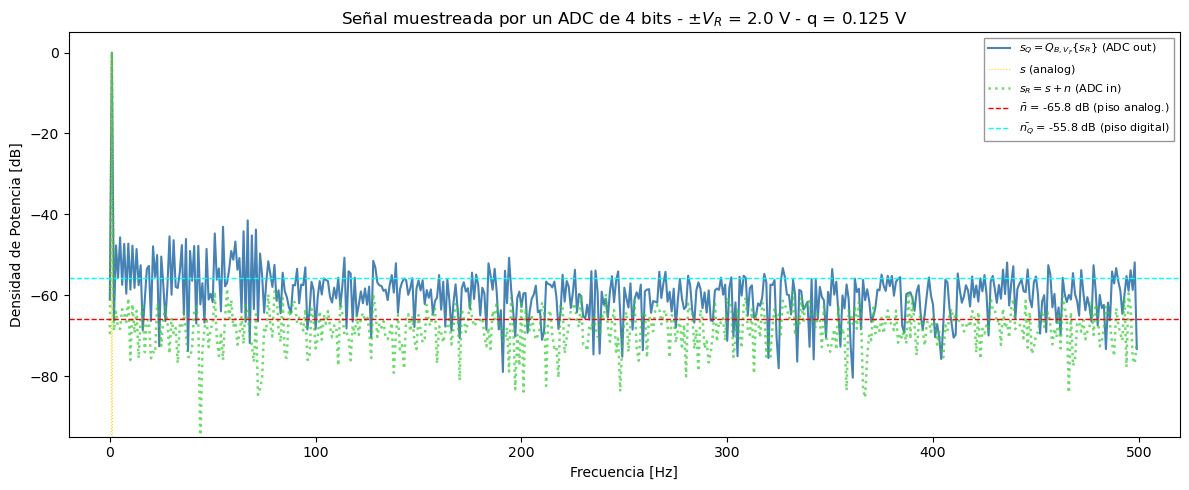

In [122]:
EspectroSr = np.fft.fft(Sr)/muestras
Mod_EspSr = 2 * (np.abs(EspectroSr))**2 

EspectroSq = np.fft.fft(sq)/muestras
Mod_EspSq = 2 * (np.abs(EspectroSq))**2 

EspectroXX = np.fft.fft(xx)/muestras
Mod_EspXX = 2 * (np.abs(EspectroXX))**2 

Sr_db = 10 * np.log10(Mod_EspSr) 
sq_db = 10 * np.log10(Mod_EspSq) 
xx_db = 10 * np.log10(Mod_EspXX)

Frec = np.fft.fftfreq(muestras, Ts)

piso_analog = 10 * np.log10(pr / (fs/2))      # densidad espectral del ruido aditivo (potencia/ancho de banda)
piso_digital = 10 * np.log10(Pq / (fs/2))     # densidad espectral del ruido de cuantización

mitad = muestras // 2
Frec_pos = Frec[:mitad]

# Espectros solo frecuencias positivas
Sr_db_pos = Sr_db[:mitad]
sq_db_pos = sq_db[:mitad]
xx_db_pos = xx_db[:mitad]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(Frec_pos, sq_db_pos, color='steelblue', linewidth=1.5, linestyle='-',
        label=r'$s_Q = Q_{B,V_F}\{s_R\}$ (ADC out)')
ax.plot(Frec_pos, xx_db_pos, color='gold', linewidth=0.8, linestyle=':',
        label=r'$s$ (analog)')
ax.plot(Frec_pos, Sr_db_pos, color='limegreen', linewidth=1.8, linestyle=':',
        markersize=2, alpha=0.7, label=r'$s_R = s + n$ (ADC in)')
ax.axhline(piso_analog,  color='red',  linestyle='--', linewidth=1,
           label=fr'$\bar{{n}}$ = {piso_analog:.1f} dB (piso analog.)')
ax.axhline(piso_digital, color='cyan', linestyle='--', linewidth=1,
           label=fr'$\bar{{n_Q}}$ = {piso_digital:.1f} dB (piso digital)')

ax.set_title(f"Señal muestreada por un ADC de {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylim([-95, 5]) 
ax.set_ylabel("Densidad de Potencia [dB]")
ax.set_xlim([-20, fs/2 + 20])
ax.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=8)

plt.tight_layout()
plt.show()

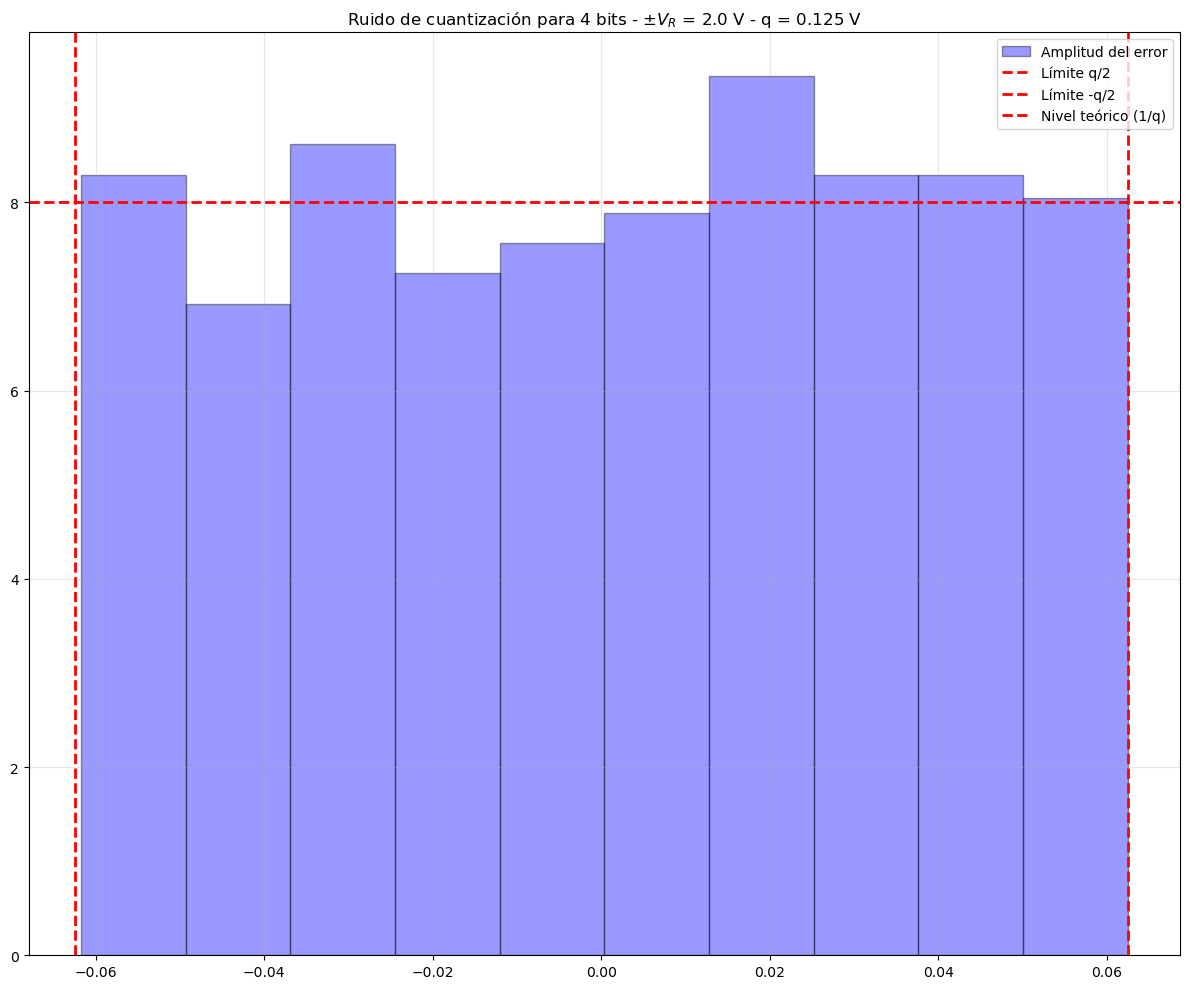

In [71]:
Eq = sq - Sr

plt.figure(figsize=(12, 10))
plt.subplot(1, 1, 1)
plt.hist(Eq, bins= 10, density=True, color='blue', alpha=0.4, edgecolor='black', label='Amplitud del error')

# Líneas guía teóricas: el error de cuantización debe vivir entre -q/2 y q/2
plt.axvline(x=qq/2, color='red', linestyle='--', linewidth=2, label='Límite q/2')
plt.axvline(x=-qq/2, color='red', linestyle='--', linewidth=2, label='Límite -q/2')

# Valor teórico de la PDF uniforme: 1/q
plt.axhline(y=1/qq, color='red', linestyle='--', linewidth=2, label='Nivel teórico (1/q)')

plt.title(f'Ruido de cuantización para {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Segunda combinacion: kn = 1/10, B = 8

In [72]:
B = 8  # bits
Vfs = 2  # Volts

qq = ( Vfs) / (2**B) 
Pq = qq**2 / 12

A = np.sqrt(2)
dc = 0
fs = 1000
Ts= 1/fs
fase = 0
muestras = 1000
f0 = fs/muestras
Ps = (A**2)/ 2 

kn = 1/10

pr = kn * Pq 

snr = Ps / pr

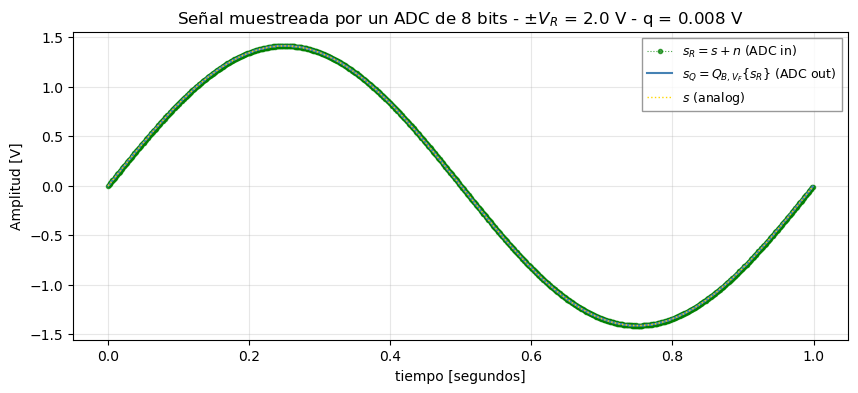

In [73]:
tt1, xx1 = mi_funcion_sen_ruido(A, dc, f0, fase, muestras, fs, snr, pr)
tt, xx = mi_funcion_sen(A, dc, f0, fase, muestras, fs)


Sr = xx1

sq = np.round(Sr / qq) * qq

plt.figure(figsize=(10, 4))
plt.plot(tt1, Sr, color='green', linewidth=0.8, linestyle=':', marker ='o', markersize=3, alpha=0.7, label=r'$s_R = s + n$ (ADC in)')
plt.plot(tt1, sq, color='steelblue', linewidth=1.5, linestyle='-', label=r'$s_Q = Q_{B,V_F}\{s_R\}$ (ADC out)')
plt.plot(tt, xx, color='gold', linewidth=1, linestyle=':', label=r'$s$ (analog)')
plt.title(f"Señal muestreada por un ADC de {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V")
plt.xlabel("tiempo [segundos]")
plt.ylabel("Amplitud [V]")
plt.grid(True, alpha=0.3)
plt.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=9)
plt.show()

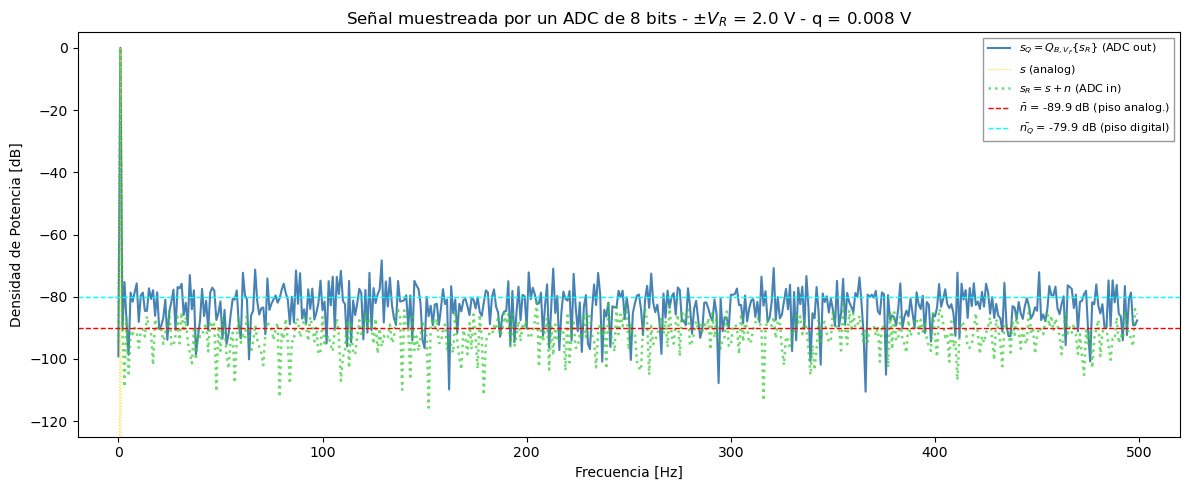

In [76]:
EspectroSr = np.fft.fft(Sr)/muestras
Mod_EspSr = 2 * (np.abs(EspectroSr))**2 

EspectroSq = np.fft.fft(sq)/muestras
Mod_EspSq = 2 * (np.abs(EspectroSq))**2 

EspectroXX = np.fft.fft(xx)/muestras
Mod_EspXX = 2 * (np.abs(EspectroXX))**2 

Sr_db = 10 * np.log10(Mod_EspSr) 
sq_db = 10 * np.log10(Mod_EspSq) 
xx_db = 10 * np.log10(Mod_EspXX)

Frec = np.fft.fftfreq(muestras, Ts)

piso_analog = 10 * np.log10(pr / (fs/2))      # densidad espectral del ruido aditivo (potencia/ancho de banda)
piso_digital = 10 * np.log10(Pq / (fs/2))     # densidad espectral del ruido de cuantización

mitad = muestras // 2
Frec_pos = Frec[:mitad]

# Espectros solo frecuencias positivas
Sr_db_pos = Sr_db[:mitad]
sq_db_pos = sq_db[:mitad]
xx_db_pos = xx_db[:mitad]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(Frec_pos, sq_db_pos, color='steelblue', linewidth=1.5, linestyle='-',
        label=r'$s_Q = Q_{B,V_F}\{s_R\}$ (ADC out)')
ax.plot(Frec_pos, xx_db_pos, color='gold', linewidth=0.8, linestyle=':',
        label=r'$s$ (analog)')
ax.plot(Frec_pos, Sr_db_pos, color='limegreen', linewidth=1.8, linestyle=':',
        markersize=2, alpha=0.7, label=r'$s_R = s + n$ (ADC in)')
ax.axhline(piso_analog,  color='red',  linestyle='--', linewidth=1,
           label=fr'$\bar{{n}}$ = {piso_analog:.1f} dB (piso analog.)')
ax.axhline(piso_digital, color='cyan', linestyle='--', linewidth=1,
           label=fr'$\bar{{n_Q}}$ = {piso_digital:.1f} dB (piso digital)')

ax.set_title(f"Señal muestreada por un ADC de {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylim([-125, 5]) 
ax.set_ylabel("Densidad de Potencia [dB]")
ax.set_xlim([-20, fs/2 + 20])
ax.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=8)

plt.tight_layout()
plt.show()

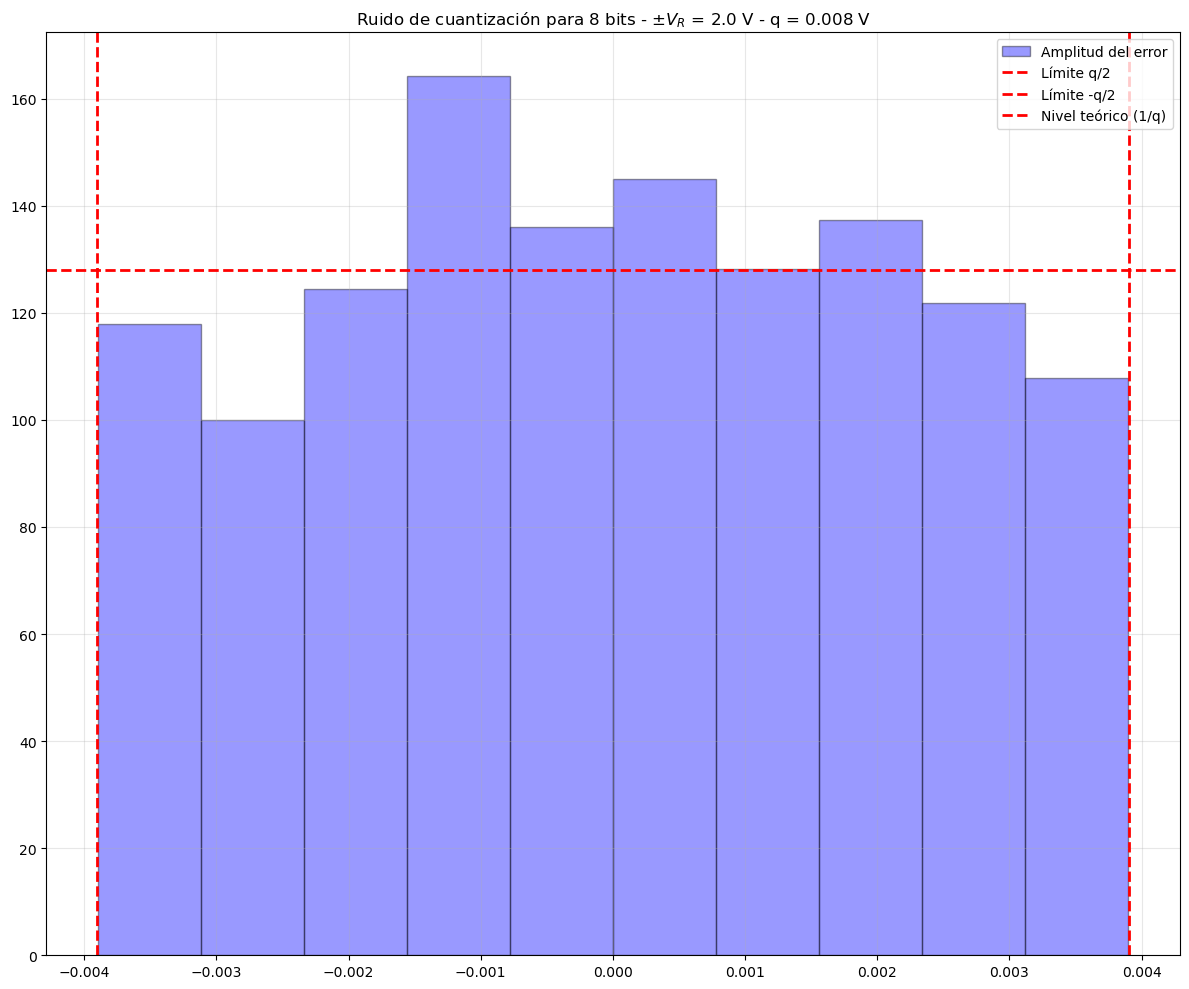

In [77]:
Eq = sq - Sr

plt.figure(figsize=(12, 10))
plt.subplot(1, 1, 1)
plt.hist(Eq, bins= 10, density=True, color='blue', alpha=0.4, edgecolor='black', label='Amplitud del error')

# Líneas guía teóricas: el error de cuantización debe vivir entre -q/2 y q/2
plt.axvline(x=qq/2, color='red', linestyle='--', linewidth=2, label='Límite q/2')
plt.axvline(x=-qq/2, color='red', linestyle='--', linewidth=2, label='Límite -q/2')

# Valor teórico de la PDF uniforme: 1/q
plt.axhline(y=1/qq, color='red', linestyle='--', linewidth=2, label='Nivel teórico (1/q)')

plt.title(f'Ruido de cuantización para {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Tercera combinacion: kn = 1/10, B = 16

In [78]:
B = 16  # bits
Vfs = 2  # Volts

qq = ( Vfs) / (2**B) 
Pq = qq**2 / 12

A = np.sqrt(2)
dc = 0
fs = 1000
Ts= 1/fs
fase = 0
muestras = 1000
f0 = fs/muestras
Ps = (A**2)/ 2 

kn = 1/10

pr = kn * Pq 

snr = Ps / pr

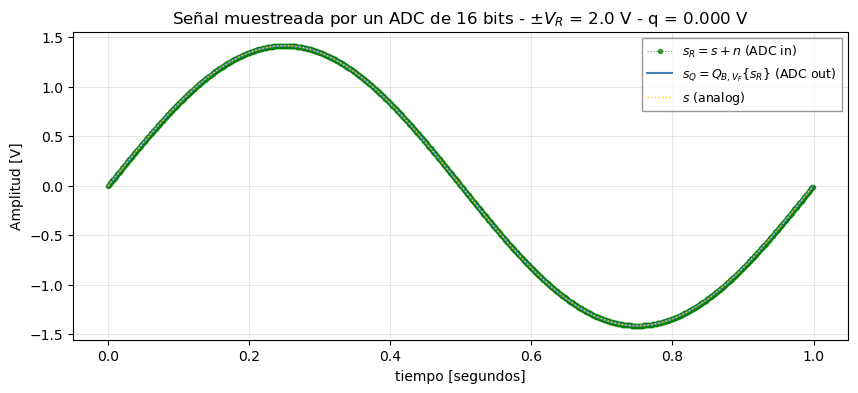

In [79]:
tt1, xx1 = mi_funcion_sen_ruido(A, dc, f0, fase, muestras, fs, snr, pr)
tt, xx = mi_funcion_sen(A, dc, f0, fase, muestras, fs)


Sr = xx1

sq = np.round(Sr / qq) * qq

plt.figure(figsize=(10, 4))
plt.plot(tt1, Sr, color='green', linewidth=0.8, linestyle=':', marker ='o', markersize=3, alpha=0.7, label=r'$s_R = s + n$ (ADC in)')
plt.plot(tt1, sq, color='steelblue', linewidth=1.5, linestyle='-', label=r'$s_Q = Q_{B,V_F}\{s_R\}$ (ADC out)')
plt.plot(tt, xx, color='gold', linewidth=1, linestyle=':', label=r'$s$ (analog)')
plt.title(f"Señal muestreada por un ADC de {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V")
plt.xlabel("tiempo [segundos]")
plt.ylabel("Amplitud [V]")
plt.grid(True, alpha=0.3)
plt.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=9)
plt.show()

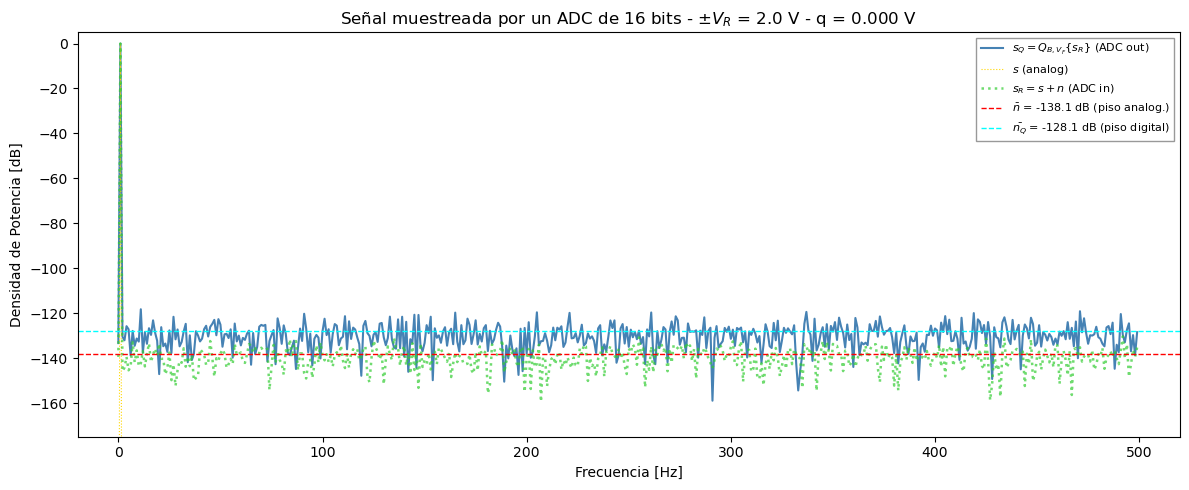

In [80]:
EspectroSr = np.fft.fft(Sr)/muestras
Mod_EspSr = 2 * (np.abs(EspectroSr))**2 

EspectroSq = np.fft.fft(sq)/muestras
Mod_EspSq = 2 * (np.abs(EspectroSq))**2 

EspectroXX = np.fft.fft(xx)/muestras
Mod_EspXX = 2 * (np.abs(EspectroXX))**2 

Sr_db = 10 * np.log10(Mod_EspSr) 
sq_db = 10 * np.log10(Mod_EspSq) 
xx_db = 10 * np.log10(Mod_EspXX)

Frec = np.fft.fftfreq(muestras, Ts)

piso_analog = 10 * np.log10(pr / (fs/2))      # densidad espectral del ruido aditivo (potencia/ancho de banda)
piso_digital = 10 * np.log10(Pq / (fs/2))     # densidad espectral del ruido de cuantización

mitad = muestras // 2
Frec_pos = Frec[:mitad]

# Espectros solo frecuencias positivas
Sr_db_pos = Sr_db[:mitad]
sq_db_pos = sq_db[:mitad]
xx_db_pos = xx_db[:mitad]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(Frec_pos, sq_db_pos, color='steelblue', linewidth=1.5, linestyle='-',
        label=r'$s_Q = Q_{B,V_F}\{s_R\}$ (ADC out)')
ax.plot(Frec_pos, xx_db_pos, color='gold', linewidth=0.8, linestyle=':',
        label=r'$s$ (analog)')
ax.plot(Frec_pos, Sr_db_pos, color='limegreen', linewidth=1.8, linestyle=':',
        markersize=2, alpha=0.7, label=r'$s_R = s + n$ (ADC in)')
ax.axhline(piso_analog,  color='red',  linestyle='--', linewidth=1,
           label=fr'$\bar{{n}}$ = {piso_analog:.1f} dB (piso analog.)')
ax.axhline(piso_digital, color='cyan', linestyle='--', linewidth=1,
           label=fr'$\bar{{n_Q}}$ = {piso_digital:.1f} dB (piso digital)')

ax.set_title(f"Señal muestreada por un ADC de {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylim([-175, 5]) 
ax.set_ylabel("Densidad de Potencia [dB]")
ax.set_xlim([-20, fs/2 + 20])
ax.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=8)

plt.tight_layout()
plt.show()

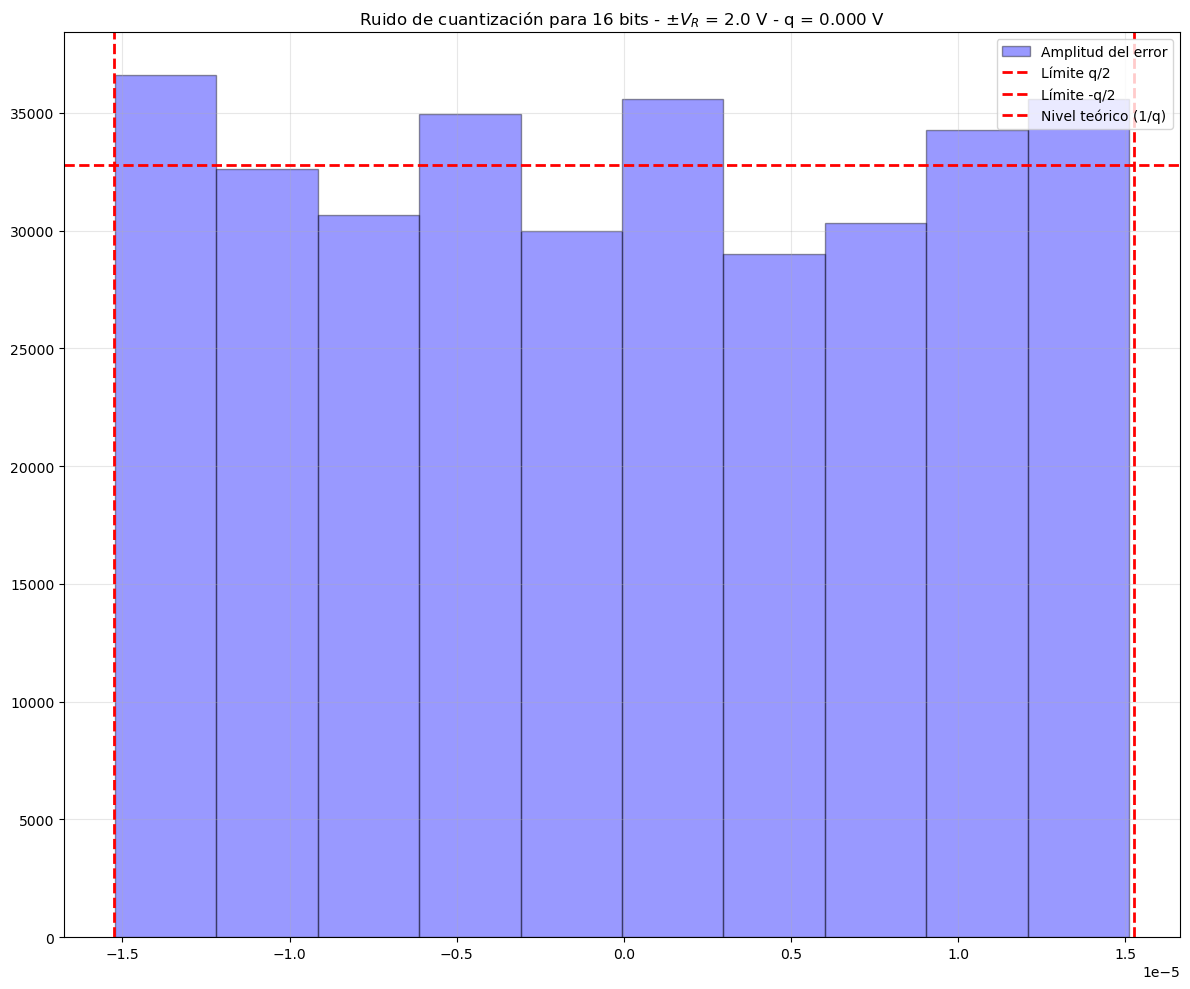

In [81]:
Eq = sq - Sr

plt.figure(figsize=(12, 10))
plt.subplot(1, 1, 1)
plt.hist(Eq, bins= 10, density=True, color='blue', alpha=0.4, edgecolor='black', label='Amplitud del error')

# Líneas guía teóricas: el error de cuantización debe vivir entre -q/2 y q/2
plt.axvline(x=qq/2, color='red', linestyle='--', linewidth=2, label='Límite q/2')
plt.axvline(x=-qq/2, color='red', linestyle='--', linewidth=2, label='Límite -q/2')

# Valor teórico de la PDF uniforme: 1/q
plt.axhline(y=1/qq, color='red', linestyle='--', linewidth=2, label='Nivel teórico (1/q)')

plt.title(f'Ruido de cuantización para {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Cuarta combinacion: kn = 1, B = 4

In [82]:
B = 4  # bits
Vfs = 2  # Volts

qq = ( Vfs) / (2**B) 
Pq = qq**2 / 12

A = np.sqrt(2)
dc = 0
fs = 1000
Ts= 1/fs
fase = 0
muestras = 1000
f0 = fs/muestras
Ps = (A**2)/ 2 

kn = 1

pr = kn * Pq 

snr = Ps / pr

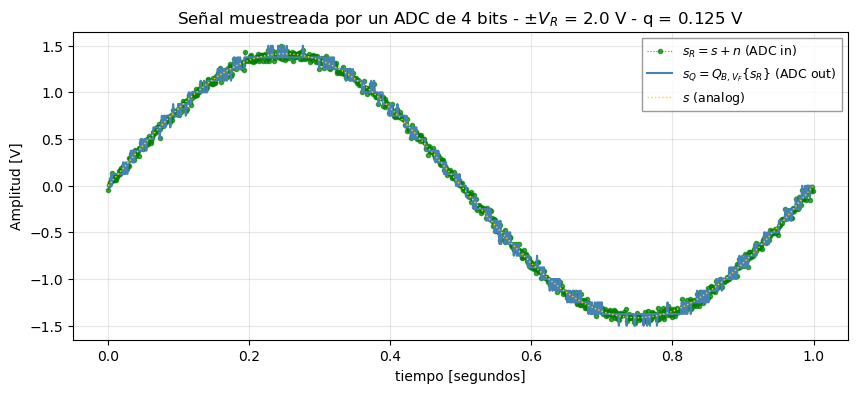

In [83]:
tt1, xx1 = mi_funcion_sen_ruido(A, dc, f0, fase, muestras, fs, snr, pr)
tt, xx = mi_funcion_sen(A, dc, f0, fase, muestras, fs)


Sr = xx1

sq = np.round(Sr / qq) * qq

plt.figure(figsize=(10, 4))
plt.plot(tt1, Sr, color='green', linewidth=0.8, linestyle=':', marker ='o', markersize=3, alpha=0.7, label=r'$s_R = s + n$ (ADC in)')
plt.plot(tt1, sq, color='steelblue', linewidth=1.5, linestyle='-', label=r'$s_Q = Q_{B,V_F}\{s_R\}$ (ADC out)')
plt.plot(tt, xx, color='gold', linewidth=1, linestyle=':', label=r'$s$ (analog)')
plt.title(f"Señal muestreada por un ADC de {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V")
plt.xlabel("tiempo [segundos]")
plt.ylabel("Amplitud [V]")
plt.grid(True, alpha=0.3)
plt.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=9)
plt.show()

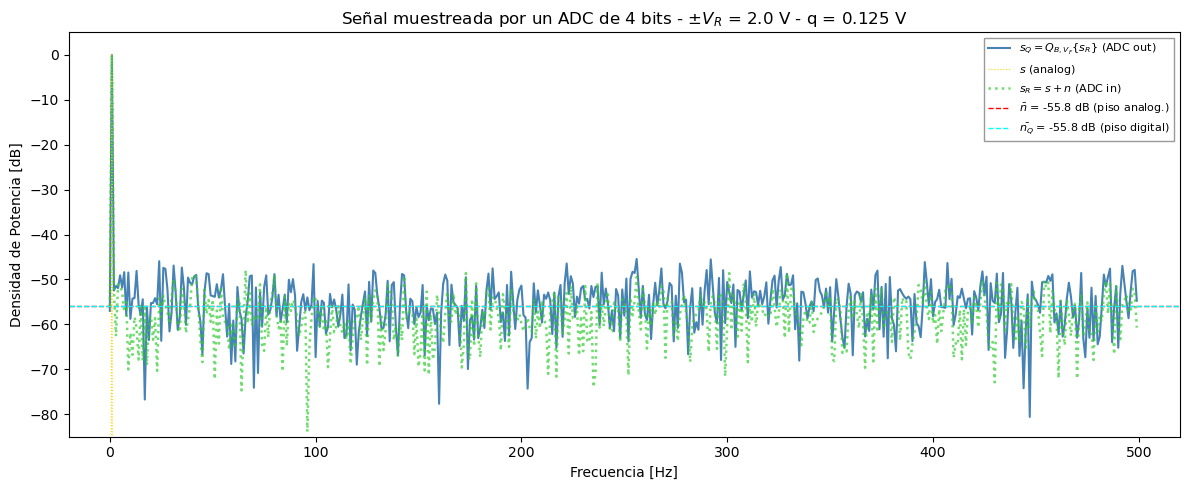

In [85]:
EspectroSr = np.fft.fft(Sr)/muestras
Mod_EspSr = 2 * (np.abs(EspectroSr))**2 

EspectroSq = np.fft.fft(sq)/muestras
Mod_EspSq = 2 * (np.abs(EspectroSq))**2 

EspectroXX = np.fft.fft(xx)/muestras
Mod_EspXX = 2 * (np.abs(EspectroXX))**2 

Sr_db = 10 * np.log10(Mod_EspSr) 
sq_db = 10 * np.log10(Mod_EspSq) 
xx_db = 10 * np.log10(Mod_EspXX)

Frec = np.fft.fftfreq(muestras, Ts)

piso_analog = 10 * np.log10(pr / (fs/2))      # densidad espectral del ruido aditivo (potencia/ancho de banda)
piso_digital = 10 * np.log10(Pq / (fs/2))     # densidad espectral del ruido de cuantización

mitad = muestras // 2
Frec_pos = Frec[:mitad]

# Espectros solo frecuencias positivas
Sr_db_pos = Sr_db[:mitad]
sq_db_pos = sq_db[:mitad]
xx_db_pos = xx_db[:mitad]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(Frec_pos, sq_db_pos, color='steelblue', linewidth=1.5, linestyle='-',
        label=r'$s_Q = Q_{B,V_F}\{s_R\}$ (ADC out)')
ax.plot(Frec_pos, xx_db_pos, color='gold', linewidth=0.8, linestyle=':',
        label=r'$s$ (analog)')
ax.plot(Frec_pos, Sr_db_pos, color='limegreen', linewidth=1.8, linestyle=':',
        markersize=2, alpha=0.7, label=r'$s_R = s + n$ (ADC in)')
ax.axhline(piso_analog,  color='red',  linestyle='--', linewidth=1,
           label=fr'$\bar{{n}}$ = {piso_analog:.1f} dB (piso analog.)')
ax.axhline(piso_digital, color='cyan', linestyle='--', linewidth=1,
           label=fr'$\bar{{n_Q}}$ = {piso_digital:.1f} dB (piso digital)')

ax.set_title(f"Señal muestreada por un ADC de {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylim([-85, 5]) 
ax.set_ylabel("Densidad de Potencia [dB]")
ax.set_xlim([-20, fs/2 + 20])
ax.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=8)

plt.tight_layout()
plt.show()

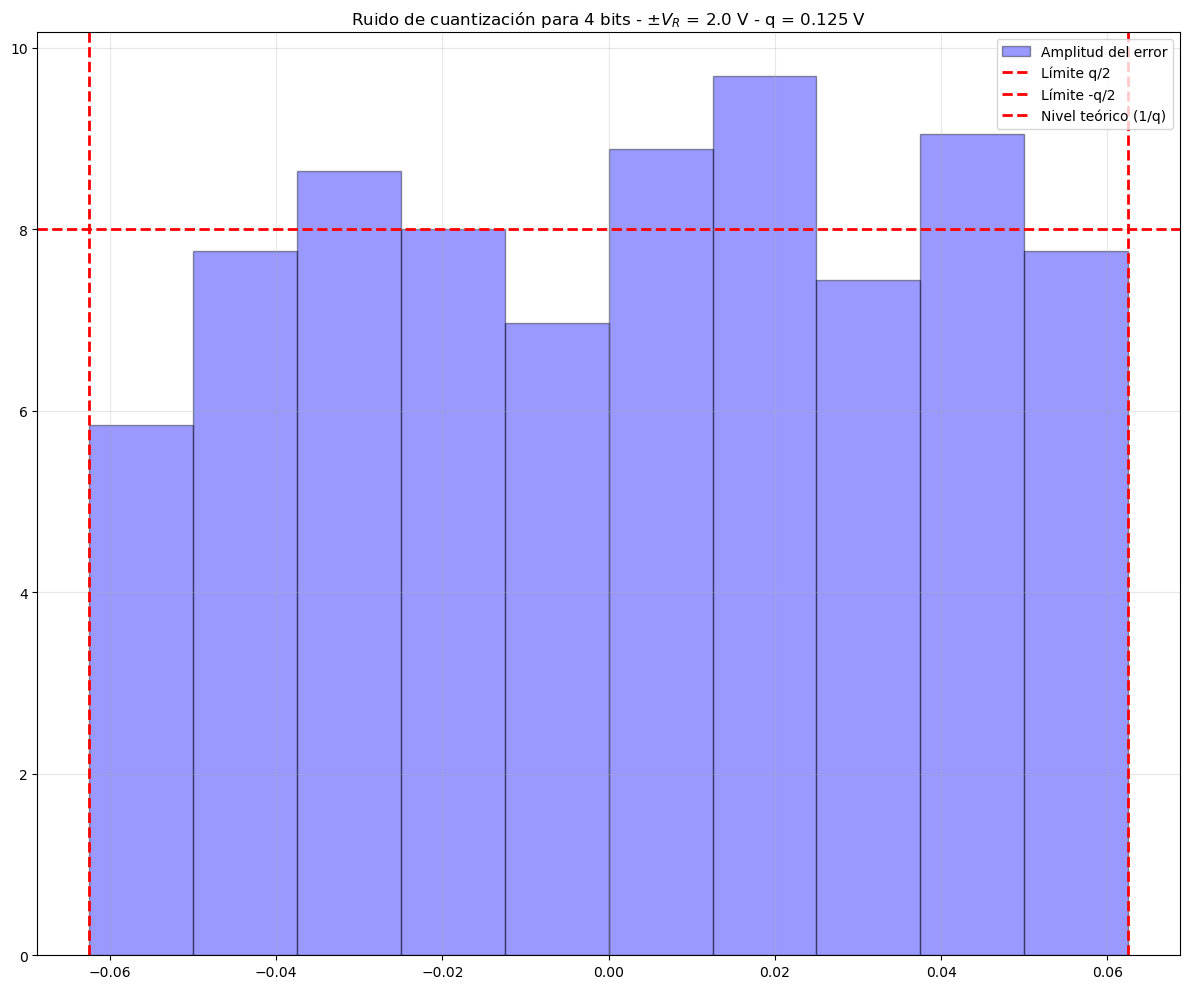

In [86]:
Eq = sq - Sr

plt.figure(figsize=(12, 10))
plt.subplot(1, 1, 1)
plt.hist(Eq, bins= 10, density=True, color='blue', alpha=0.4, edgecolor='black', label='Amplitud del error')

# Líneas guía teóricas: el error de cuantización debe vivir entre -q/2 y q/2
plt.axvline(x=qq/2, color='red', linestyle='--', linewidth=2, label='Límite q/2')
plt.axvline(x=-qq/2, color='red', linestyle='--', linewidth=2, label='Límite -q/2')

# Valor teórico de la PDF uniforme: 1/q
plt.axhline(y=1/qq, color='red', linestyle='--', linewidth=2, label='Nivel teórico (1/q)')

plt.title(f'Ruido de cuantización para {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Quinta combinacion: kn = 1, B = 8

In [87]:
B = 8  # bits
Vfs = 2  # Volts

qq = ( Vfs) / (2**B) 
Pq = qq**2 / 12

A = np.sqrt(2)
dc = 0
fs = 1000
Ts= 1/fs
fase = 0
muestras = 1000
f0 = fs/muestras
Ps = (A**2)/ 2 

kn = 1

pr = kn * Pq 

snr = Ps / pr

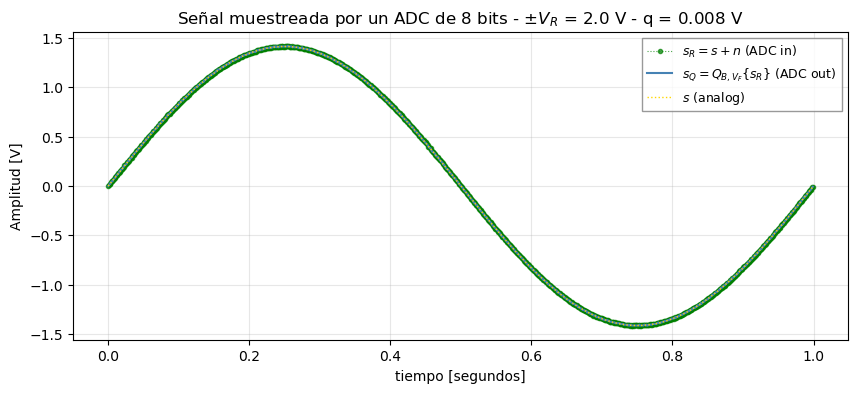

In [88]:
tt1, xx1 = mi_funcion_sen_ruido(A, dc, f0, fase, muestras, fs, snr, pr)
tt, xx = mi_funcion_sen(A, dc, f0, fase, muestras, fs)


Sr = xx1

sq = np.round(Sr / qq) * qq

plt.figure(figsize=(10, 4))
plt.plot(tt1, Sr, color='green', linewidth=0.8, linestyle=':', marker ='o', markersize=3, alpha=0.7, label=r'$s_R = s + n$ (ADC in)')
plt.plot(tt1, sq, color='steelblue', linewidth=1.5, linestyle='-', label=r'$s_Q = Q_{B,V_F}\{s_R\}$ (ADC out)')
plt.plot(tt, xx, color='gold', linewidth=1, linestyle=':', label=r'$s$ (analog)')
plt.title(f"Señal muestreada por un ADC de {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V")
plt.xlabel("tiempo [segundos]")
plt.ylabel("Amplitud [V]")
plt.grid(True, alpha=0.3)
plt.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=9)
plt.show()

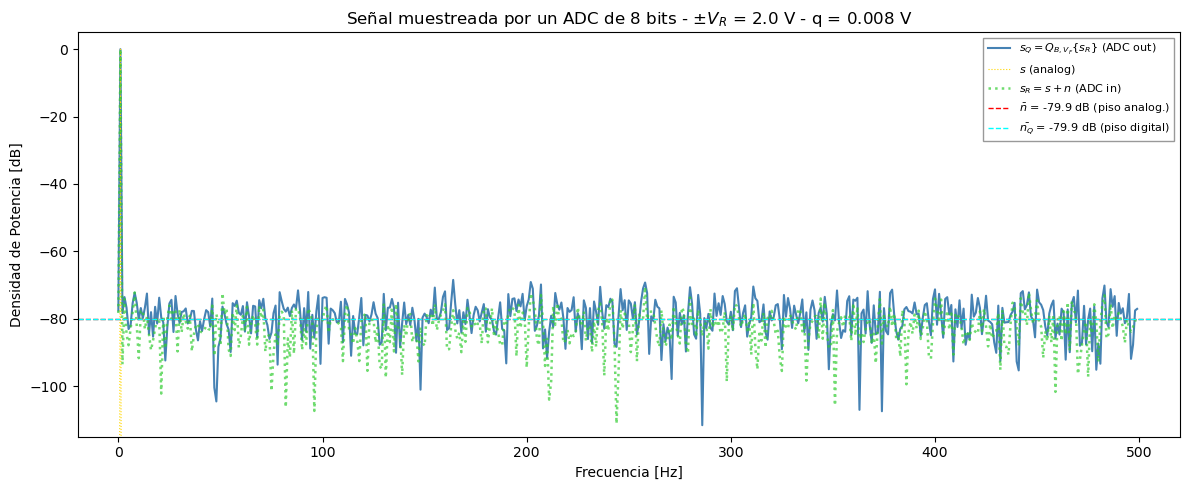

In [91]:
EspectroSr = np.fft.fft(Sr)/muestras
Mod_EspSr = 2 * (np.abs(EspectroSr))**2 

EspectroSq = np.fft.fft(sq)/muestras
Mod_EspSq = 2 * (np.abs(EspectroSq))**2 

EspectroXX = np.fft.fft(xx)/muestras
Mod_EspXX = 2 * (np.abs(EspectroXX))**2 

Sr_db = 10 * np.log10(Mod_EspSr) 
sq_db = 10 * np.log10(Mod_EspSq) 
xx_db = 10 * np.log10(Mod_EspXX)

Frec = np.fft.fftfreq(muestras, Ts)

piso_analog = 10 * np.log10(pr / (fs/2))      # densidad espectral del ruido aditivo (potencia/ancho de banda)
piso_digital = 10 * np.log10(Pq / (fs/2))     # densidad espectral del ruido de cuantización

mitad = muestras // 2
Frec_pos = Frec[:mitad]

# Espectros solo frecuencias positivas
Sr_db_pos = Sr_db[:mitad]
sq_db_pos = sq_db[:mitad]
xx_db_pos = xx_db[:mitad]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(Frec_pos, sq_db_pos, color='steelblue', linewidth=1.5, linestyle='-',
        label=r'$s_Q = Q_{B,V_F}\{s_R\}$ (ADC out)')
ax.plot(Frec_pos, xx_db_pos, color='gold', linewidth=0.8, linestyle=':',
        label=r'$s$ (analog)')
ax.plot(Frec_pos, Sr_db_pos, color='limegreen', linewidth=1.8, linestyle=':',
        markersize=2, alpha=0.7, label=r'$s_R = s + n$ (ADC in)')
ax.axhline(piso_analog,  color='red',  linestyle='--', linewidth=1,
           label=fr'$\bar{{n}}$ = {piso_analog:.1f} dB (piso analog.)')
ax.axhline(piso_digital, color='cyan', linestyle='--', linewidth=1,
           label=fr'$\bar{{n_Q}}$ = {piso_digital:.1f} dB (piso digital)')

ax.set_title(f"Señal muestreada por un ADC de {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylim([-115, 5]) 
ax.set_ylabel("Densidad de Potencia [dB]")
ax.set_xlim([-20, fs/2 + 20])
ax.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=8)

plt.tight_layout()
plt.show()

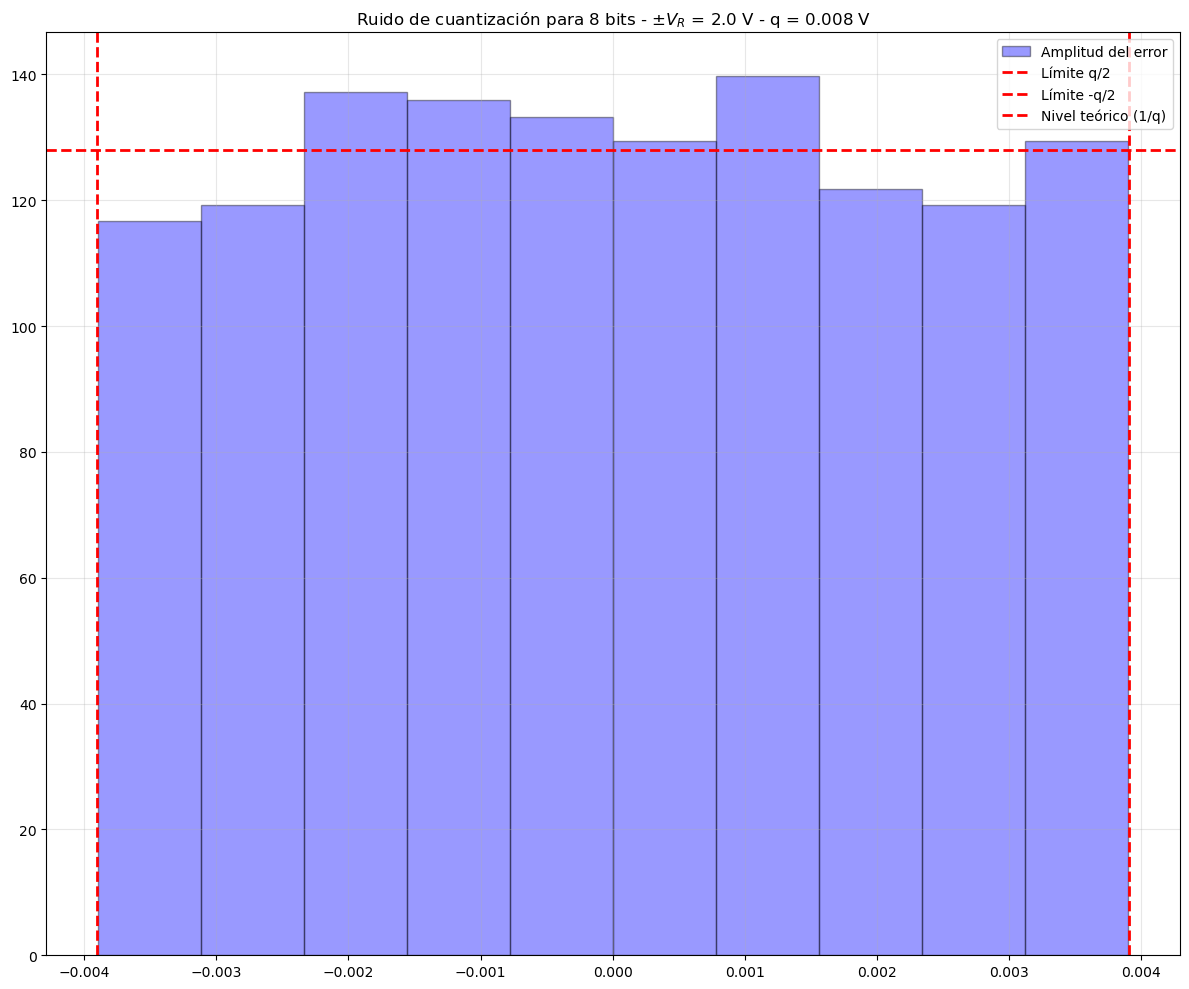

In [92]:
Eq = sq - Sr

plt.figure(figsize=(12, 10))
plt.subplot(1, 1, 1)
plt.hist(Eq, bins= 10, density=True, color='blue', alpha=0.4, edgecolor='black', label='Amplitud del error')

# Líneas guía teóricas: el error de cuantización debe vivir entre -q/2 y q/2
plt.axvline(x=qq/2, color='red', linestyle='--', linewidth=2, label='Límite q/2')
plt.axvline(x=-qq/2, color='red', linestyle='--', linewidth=2, label='Límite -q/2')

# Valor teórico de la PDF uniforme: 1/q
plt.axhline(y=1/qq, color='red', linestyle='--', linewidth=2, label='Nivel teórico (1/q)')

plt.title(f'Ruido de cuantización para {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Sexta combinacion: kn = 1, B = 16

In [93]:
B = 16  # bits
Vfs = 2  # Volts

qq = ( Vfs) / (2**B) 
Pq = qq**2 / 12

A = np.sqrt(2)
dc = 0
fs = 1000
Ts= 1/fs
fase = 0
muestras = 1000
f0 = fs/muestras
Ps = (A**2)/ 2 

kn = 1

pr = kn * Pq 

snr = Ps / pr

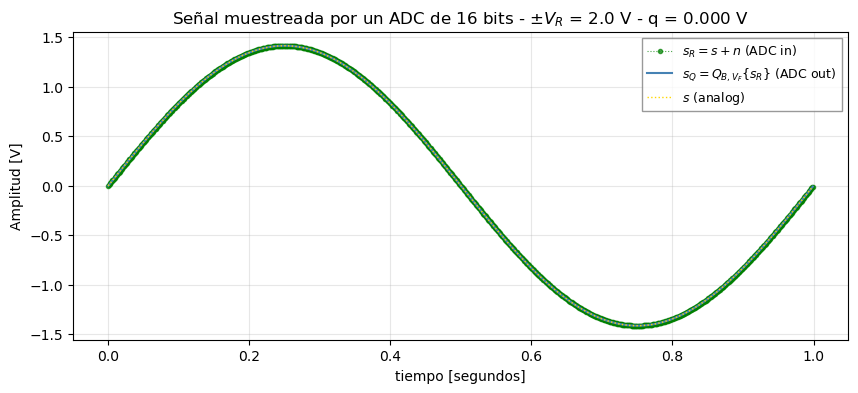

In [94]:
tt1, xx1 = mi_funcion_sen_ruido(A, dc, f0, fase, muestras, fs, snr, pr)
tt, xx = mi_funcion_sen(A, dc, f0, fase, muestras, fs)


Sr = xx1

sq = np.round(Sr / qq) * qq

plt.figure(figsize=(10, 4))
plt.plot(tt1, Sr, color='green', linewidth=0.8, linestyle=':', marker ='o', markersize=3, alpha=0.7, label=r'$s_R = s + n$ (ADC in)')
plt.plot(tt1, sq, color='steelblue', linewidth=1.5, linestyle='-', label=r'$s_Q = Q_{B,V_F}\{s_R\}$ (ADC out)')
plt.plot(tt, xx, color='gold', linewidth=1, linestyle=':', label=r'$s$ (analog)')
plt.title(f"Señal muestreada por un ADC de {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V")
plt.xlabel("tiempo [segundos]")
plt.ylabel("Amplitud [V]")
plt.grid(True, alpha=0.3)
plt.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=9)
plt.show()

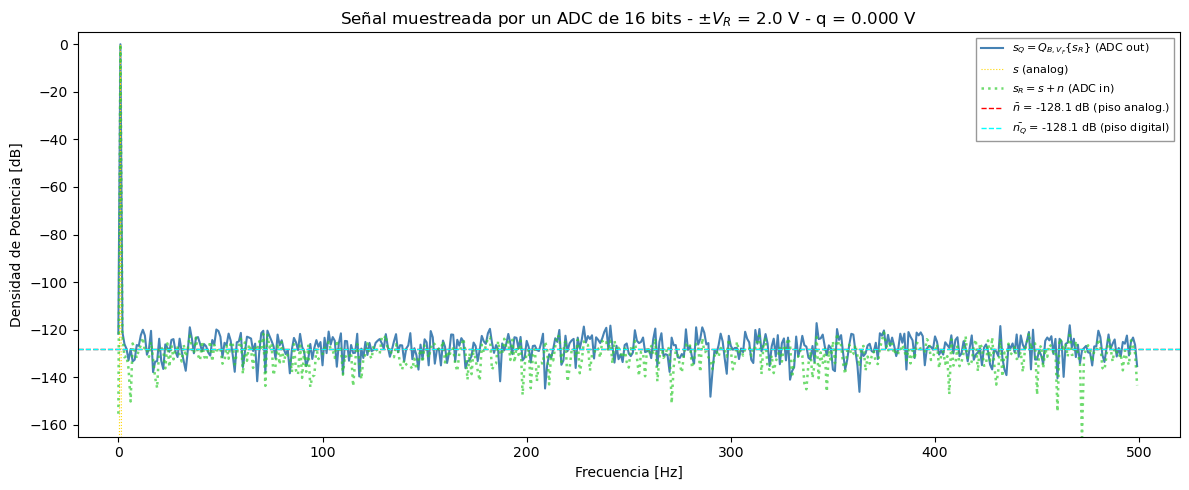

In [96]:
EspectroSr = np.fft.fft(Sr)/muestras
Mod_EspSr = 2 * (np.abs(EspectroSr))**2 

EspectroSq = np.fft.fft(sq)/muestras
Mod_EspSq = 2 * (np.abs(EspectroSq))**2 

EspectroXX = np.fft.fft(xx)/muestras
Mod_EspXX = 2 * (np.abs(EspectroXX))**2 

Sr_db = 10 * np.log10(Mod_EspSr) 
sq_db = 10 * np.log10(Mod_EspSq) 
xx_db = 10 * np.log10(Mod_EspXX)

Frec = np.fft.fftfreq(muestras, Ts)

piso_analog = 10 * np.log10(pr / (fs/2))      # densidad espectral del ruido aditivo (potencia/ancho de banda)
piso_digital = 10 * np.log10(Pq / (fs/2))     # densidad espectral del ruido de cuantización

mitad = muestras // 2
Frec_pos = Frec[:mitad]

# Espectros solo frecuencias positivas
Sr_db_pos = Sr_db[:mitad]
sq_db_pos = sq_db[:mitad]
xx_db_pos = xx_db[:mitad]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(Frec_pos, sq_db_pos, color='steelblue', linewidth=1.5, linestyle='-',
        label=r'$s_Q = Q_{B,V_F}\{s_R\}$ (ADC out)')
ax.plot(Frec_pos, xx_db_pos, color='gold', linewidth=0.8, linestyle=':',
        label=r'$s$ (analog)')
ax.plot(Frec_pos, Sr_db_pos, color='limegreen', linewidth=1.8, linestyle=':',
        markersize=2, alpha=0.7, label=r'$s_R = s + n$ (ADC in)')
ax.axhline(piso_analog,  color='red',  linestyle='--', linewidth=1,
           label=fr'$\bar{{n}}$ = {piso_analog:.1f} dB (piso analog.)')
ax.axhline(piso_digital, color='cyan', linestyle='--', linewidth=1,
           label=fr'$\bar{{n_Q}}$ = {piso_digital:.1f} dB (piso digital)')

ax.set_title(f"Señal muestreada por un ADC de {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylim([-165, 5]) 
ax.set_ylabel("Densidad de Potencia [dB]")
ax.set_xlim([-20, fs/2 + 20])
ax.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=8)

plt.tight_layout()
plt.show()

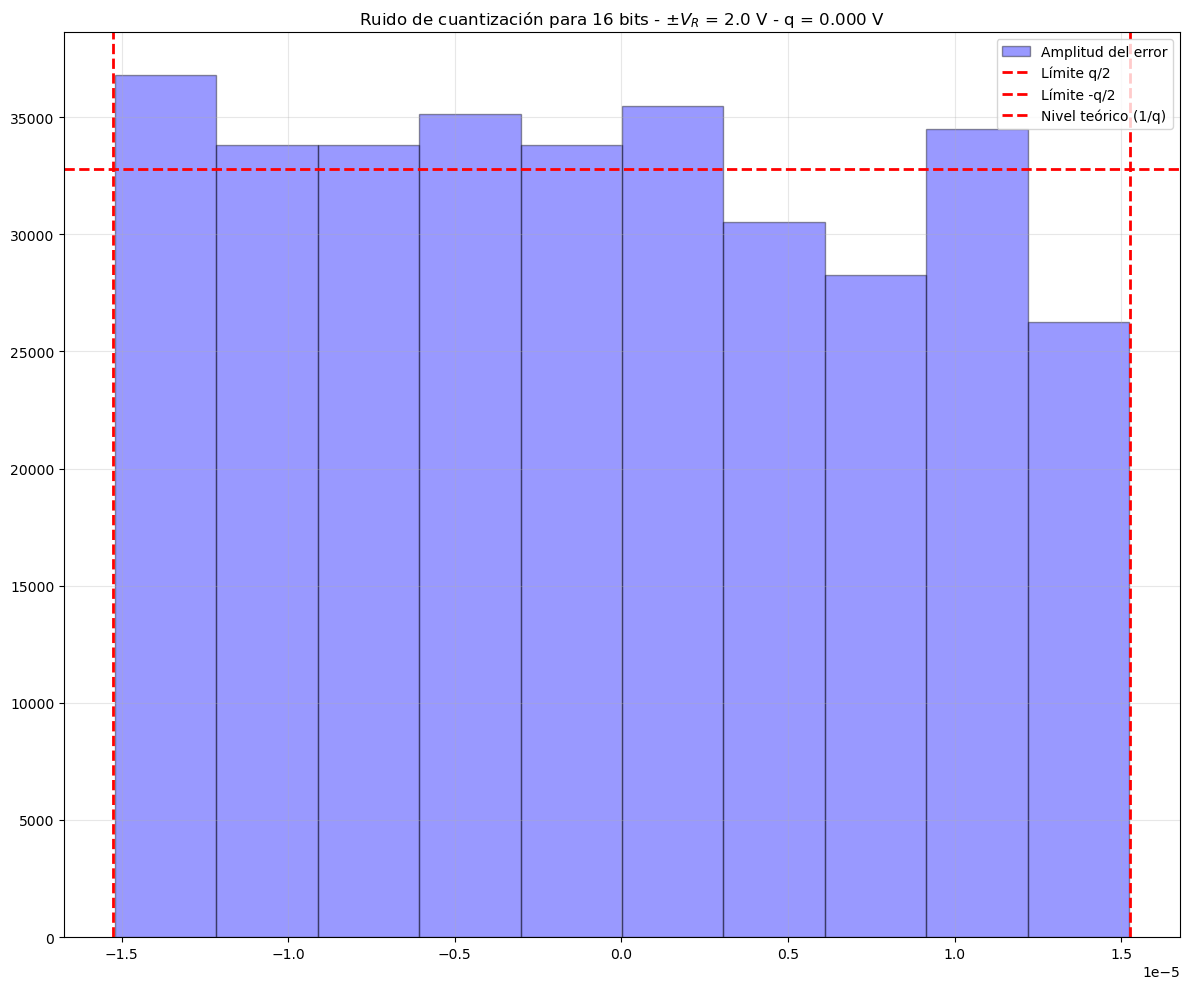

In [97]:
Eq = sq - Sr

plt.figure(figsize=(12, 10))
plt.subplot(1, 1, 1)
plt.hist(Eq, bins= 10, density=True, color='blue', alpha=0.4, edgecolor='black', label='Amplitud del error')

# Líneas guía teóricas: el error de cuantización debe vivir entre -q/2 y q/2
plt.axvline(x=qq/2, color='red', linestyle='--', linewidth=2, label='Límite q/2')
plt.axvline(x=-qq/2, color='red', linestyle='--', linewidth=2, label='Límite -q/2')

# Valor teórico de la PDF uniforme: 1/q
plt.axhline(y=1/qq, color='red', linestyle='--', linewidth=2, label='Nivel teórico (1/q)')

plt.title(f'Ruido de cuantización para {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Septima combinacion: kn = 10, B = 4

In [98]:
B = 4  # bits
Vfs = 2  # Volts

qq = ( Vfs) / (2**B) 
Pq = qq**2 / 12

A = np.sqrt(2)
dc = 0
fs = 1000
Ts= 1/fs
fase = 0
muestras = 1000
f0 = fs/muestras
Ps = (A**2)/ 2 

kn = 10

pr = kn * Pq 

snr = Ps / pr

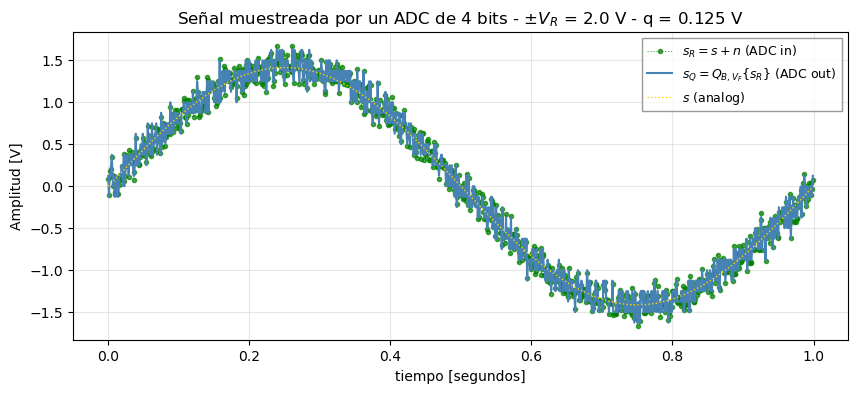

In [99]:
tt1, xx1 = mi_funcion_sen_ruido(A, dc, f0, fase, muestras, fs, snr, pr)
tt, xx = mi_funcion_sen(A, dc, f0, fase, muestras, fs)


Sr = xx1

sq = np.round(Sr / qq) * qq

plt.figure(figsize=(10, 4))
plt.plot(tt1, Sr, color='green', linewidth=0.8, linestyle=':', marker ='o', markersize=3, alpha=0.7, label=r'$s_R = s + n$ (ADC in)')
plt.plot(tt1, sq, color='steelblue', linewidth=1.5, linestyle='-', label=r'$s_Q = Q_{B,V_F}\{s_R\}$ (ADC out)')
plt.plot(tt, xx, color='gold', linewidth=1, linestyle=':', label=r'$s$ (analog)')
plt.title(f"Señal muestreada por un ADC de {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V")
plt.xlabel("tiempo [segundos]")
plt.ylabel("Amplitud [V]")
plt.grid(True, alpha=0.3)
plt.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=9)
plt.show()

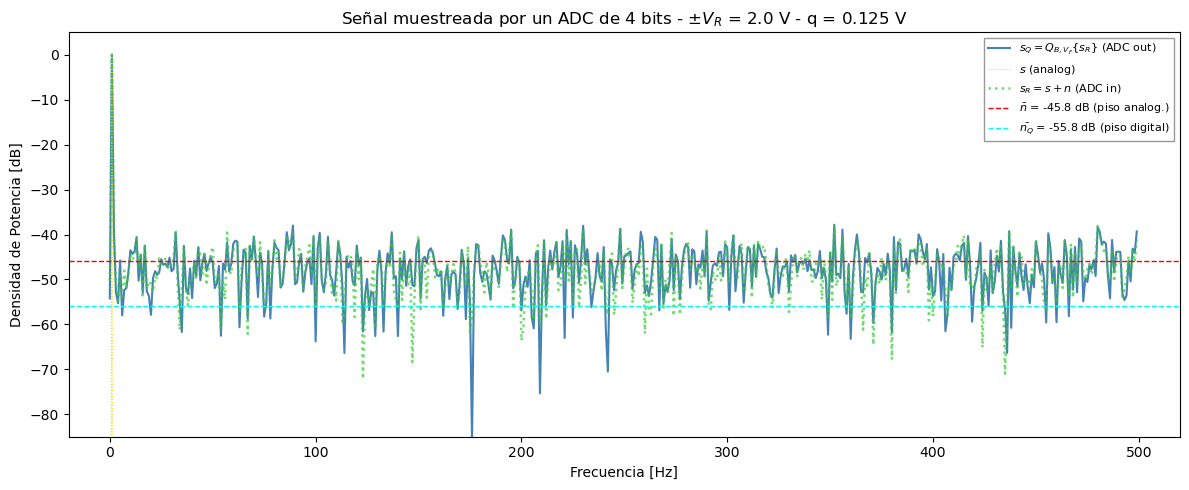

In [100]:
EspectroSr = np.fft.fft(Sr)/muestras
Mod_EspSr = 2 * (np.abs(EspectroSr))**2 

EspectroSq = np.fft.fft(sq)/muestras
Mod_EspSq = 2 * (np.abs(EspectroSq))**2 

EspectroXX = np.fft.fft(xx)/muestras
Mod_EspXX = 2 * (np.abs(EspectroXX))**2 

Sr_db = 10 * np.log10(Mod_EspSr) 
sq_db = 10 * np.log10(Mod_EspSq) 
xx_db = 10 * np.log10(Mod_EspXX)

Frec = np.fft.fftfreq(muestras, Ts)

piso_analog = 10 * np.log10(pr / (fs/2))      # densidad espectral del ruido aditivo (potencia/ancho de banda)
piso_digital = 10 * np.log10(Pq / (fs/2))     # densidad espectral del ruido de cuantización

mitad = muestras // 2
Frec_pos = Frec[:mitad]

# Espectros solo frecuencias positivas
Sr_db_pos = Sr_db[:mitad]
sq_db_pos = sq_db[:mitad]
xx_db_pos = xx_db[:mitad]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(Frec_pos, sq_db_pos, color='steelblue', linewidth=1.5, linestyle='-',
        label=r'$s_Q = Q_{B,V_F}\{s_R\}$ (ADC out)')
ax.plot(Frec_pos, xx_db_pos, color='gold', linewidth=0.8, linestyle=':',
        label=r'$s$ (analog)')
ax.plot(Frec_pos, Sr_db_pos, color='limegreen', linewidth=1.8, linestyle=':',
        markersize=2, alpha=0.7, label=r'$s_R = s + n$ (ADC in)')
ax.axhline(piso_analog,  color='red',  linestyle='--', linewidth=1,
           label=fr'$\bar{{n}}$ = {piso_analog:.1f} dB (piso analog.)')
ax.axhline(piso_digital, color='cyan', linestyle='--', linewidth=1,
           label=fr'$\bar{{n_Q}}$ = {piso_digital:.1f} dB (piso digital)')

ax.set_title(f"Señal muestreada por un ADC de {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylim([-85, 5]) 
ax.set_ylabel("Densidad de Potencia [dB]")
ax.set_xlim([-20, fs/2 + 20])
ax.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=8)

plt.tight_layout()
plt.show()

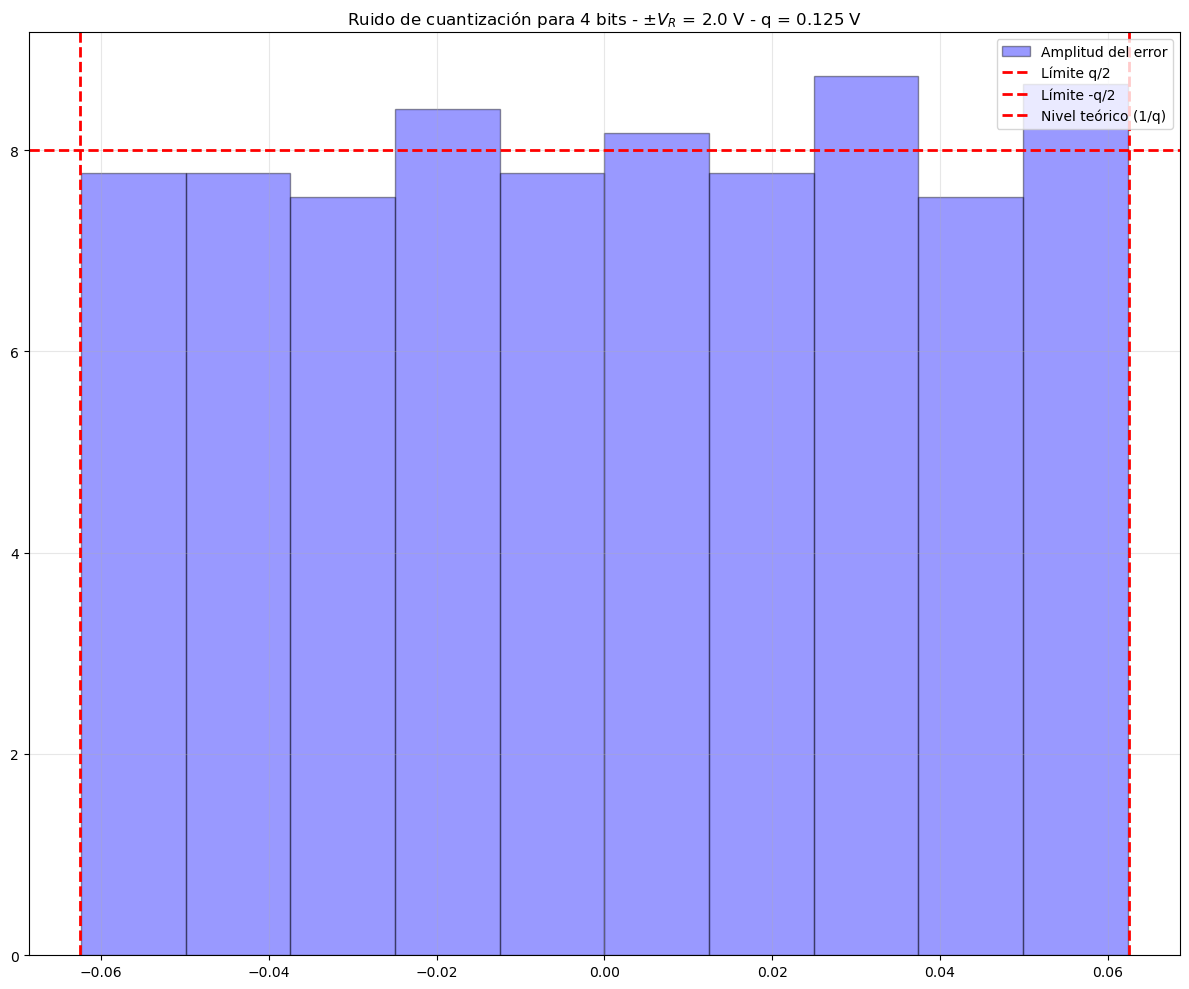

In [101]:
Eq = sq - Sr

plt.figure(figsize=(12, 10))
plt.subplot(1, 1, 1)
plt.hist(Eq, bins= 10, density=True, color='blue', alpha=0.4, edgecolor='black', label='Amplitud del error')

# Líneas guía teóricas: el error de cuantización debe vivir entre -q/2 y q/2
plt.axvline(x=qq/2, color='red', linestyle='--', linewidth=2, label='Límite q/2')
plt.axvline(x=-qq/2, color='red', linestyle='--', linewidth=2, label='Límite -q/2')

# Valor teórico de la PDF uniforme: 1/q
plt.axhline(y=1/qq, color='red', linestyle='--', linewidth=2, label='Nivel teórico (1/q)')

plt.title(f'Ruido de cuantización para {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Octava combinacion: kn = 10, B = 8

In [102]:
B = 8  # bits
Vfs = 2  # Volts

qq = ( Vfs) / (2**B) 
Pq = qq**2 / 12

A = np.sqrt(2)
dc = 0
fs = 1000
Ts= 1/fs
fase = 0
muestras = 1000
f0 = fs/muestras
Ps = (A**2)/ 2 

kn = 10

pr = kn * Pq 

snr = Ps / pr

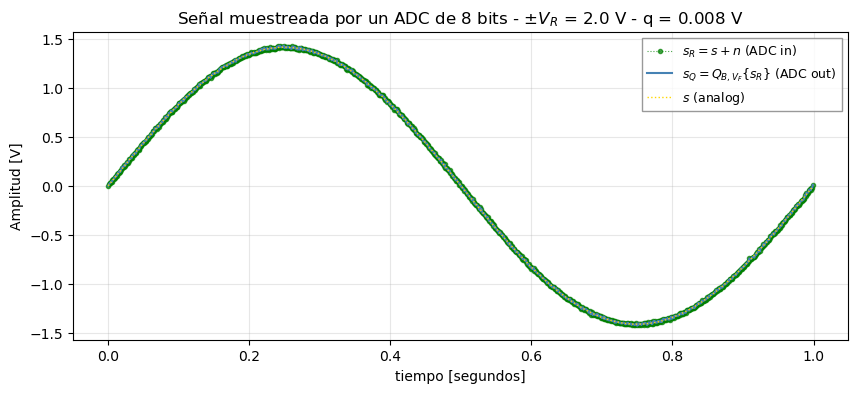

In [103]:
tt1, xx1 = mi_funcion_sen_ruido(A, dc, f0, fase, muestras, fs, snr, pr)
tt, xx = mi_funcion_sen(A, dc, f0, fase, muestras, fs)


Sr = xx1

sq = np.round(Sr / qq) * qq

plt.figure(figsize=(10, 4))
plt.plot(tt1, Sr, color='green', linewidth=0.8, linestyle=':', marker ='o', markersize=3, alpha=0.7, label=r'$s_R = s + n$ (ADC in)')
plt.plot(tt1, sq, color='steelblue', linewidth=1.5, linestyle='-', label=r'$s_Q = Q_{B,V_F}\{s_R\}$ (ADC out)')
plt.plot(tt, xx, color='gold', linewidth=1, linestyle=':', label=r'$s$ (analog)')
plt.title(f"Señal muestreada por un ADC de {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V")
plt.xlabel("tiempo [segundos]")
plt.ylabel("Amplitud [V]")
plt.grid(True, alpha=0.3)
plt.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=9)
plt.show()

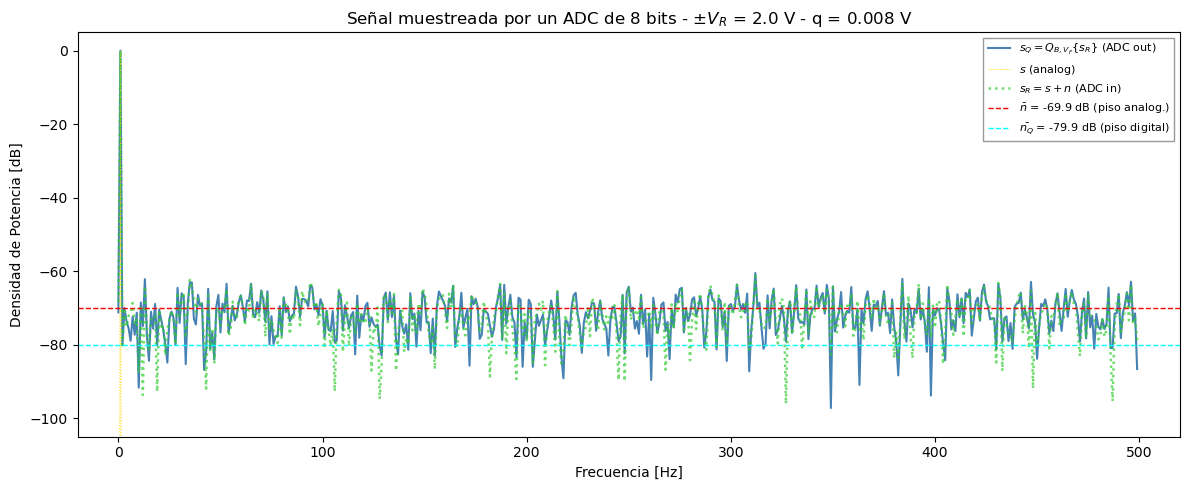

In [106]:
EspectroSr = np.fft.fft(Sr)/muestras
Mod_EspSr = 2 * (np.abs(EspectroSr))**2 

EspectroSq = np.fft.fft(sq)/muestras
Mod_EspSq = 2 * (np.abs(EspectroSq))**2 

EspectroXX = np.fft.fft(xx)/muestras
Mod_EspXX = 2 * (np.abs(EspectroXX))**2 

Sr_db = 10 * np.log10(Mod_EspSr) 
sq_db = 10 * np.log10(Mod_EspSq) 
xx_db = 10 * np.log10(Mod_EspXX)

Frec = np.fft.fftfreq(muestras, Ts)

piso_analog = 10 * np.log10(pr / (fs/2))      # densidad espectral del ruido aditivo (potencia/ancho de banda)
piso_digital = 10 * np.log10(Pq / (fs/2))     # densidad espectral del ruido de cuantización

mitad = muestras // 2
Frec_pos = Frec[:mitad]

# Espectros solo frecuencias positivas
Sr_db_pos = Sr_db[:mitad]
sq_db_pos = sq_db[:mitad]
xx_db_pos = xx_db[:mitad]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(Frec_pos, sq_db_pos, color='steelblue', linewidth=1.5, linestyle='-',
        label=r'$s_Q = Q_{B,V_F}\{s_R\}$ (ADC out)')
ax.plot(Frec_pos, xx_db_pos, color='gold', linewidth=0.8, linestyle=':',
        label=r'$s$ (analog)')
ax.plot(Frec_pos, Sr_db_pos, color='limegreen', linewidth=1.8, linestyle=':',
        markersize=2, alpha=0.7, label=r'$s_R = s + n$ (ADC in)')
ax.axhline(piso_analog,  color='red',  linestyle='--', linewidth=1,
           label=fr'$\bar{{n}}$ = {piso_analog:.1f} dB (piso analog.)')
ax.axhline(piso_digital, color='cyan', linestyle='--', linewidth=1,
           label=fr'$\bar{{n_Q}}$ = {piso_digital:.1f} dB (piso digital)')

ax.set_title(f"Señal muestreada por un ADC de {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylim([-105, 5]) 
ax.set_ylabel("Densidad de Potencia [dB]")
ax.set_xlim([-20, fs/2 + 20])
ax.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=8)

plt.tight_layout()
plt.show()

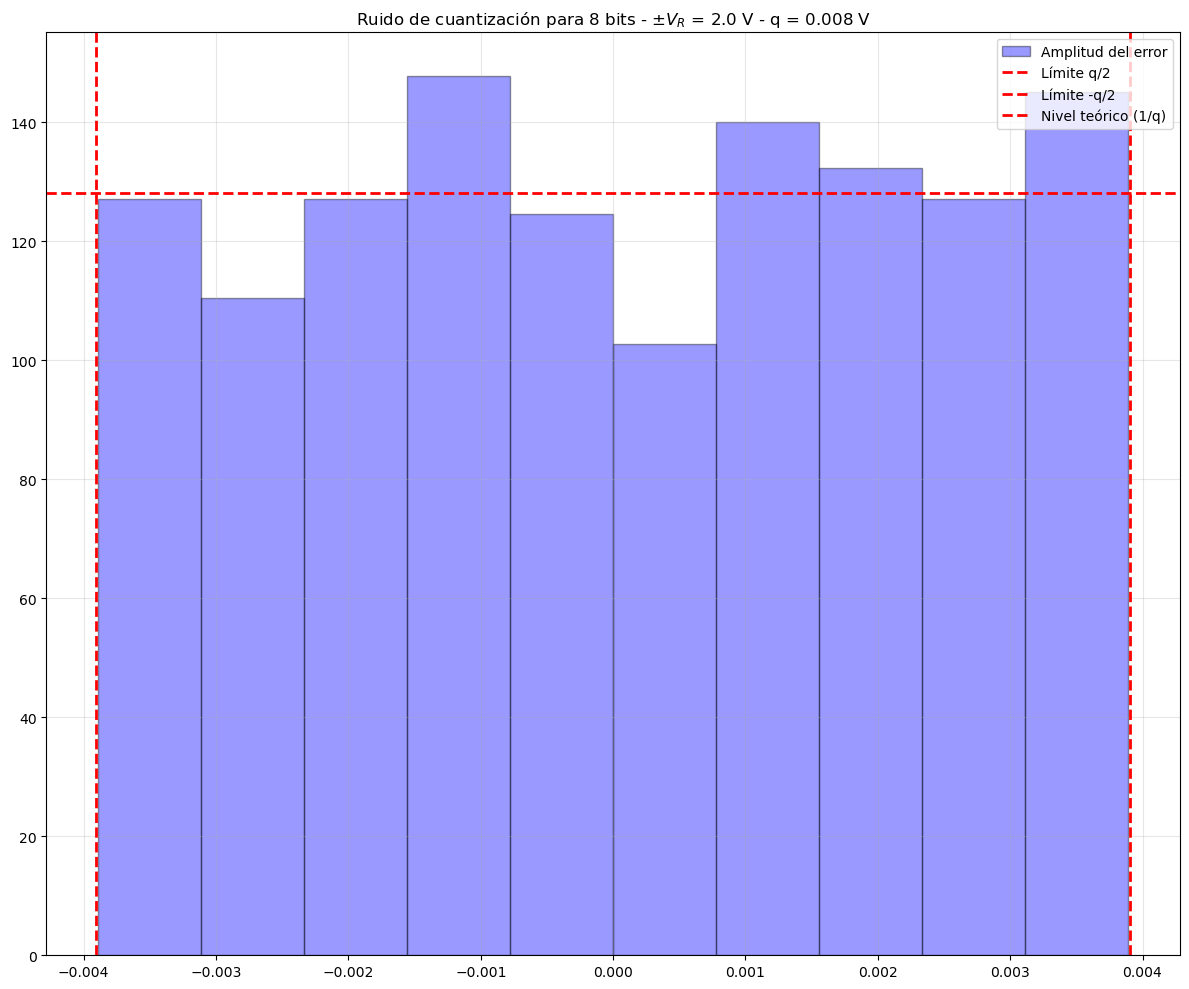

In [107]:
Eq = sq - Sr

plt.figure(figsize=(12, 10))
plt.subplot(1, 1, 1)
plt.hist(Eq, bins= 10, density=True, color='blue', alpha=0.4, edgecolor='black', label='Amplitud del error')

# Líneas guía teóricas: el error de cuantización debe vivir entre -q/2 y q/2
plt.axvline(x=qq/2, color='red', linestyle='--', linewidth=2, label='Límite q/2')
plt.axvline(x=-qq/2, color='red', linestyle='--', linewidth=2, label='Límite -q/2')

# Valor teórico de la PDF uniforme: 1/q
plt.axhline(y=1/qq, color='red', linestyle='--', linewidth=2, label='Nivel teórico (1/q)')

plt.title(f'Ruido de cuantización para {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Novena combinacion: kn = 10, B = 16

In [108]:
B = 16  # bits
Vfs = 2  # Volts

qq = ( Vfs) / (2**B) 
Pq = qq**2 / 12

A = np.sqrt(2)
dc = 0
fs = 1000
Ts= 1/fs
fase = 0
muestras = 1000
f0 = fs/muestras
Ps = (A**2)/ 2 

kn = 10

pr = kn * Pq 

snr = Ps / pr

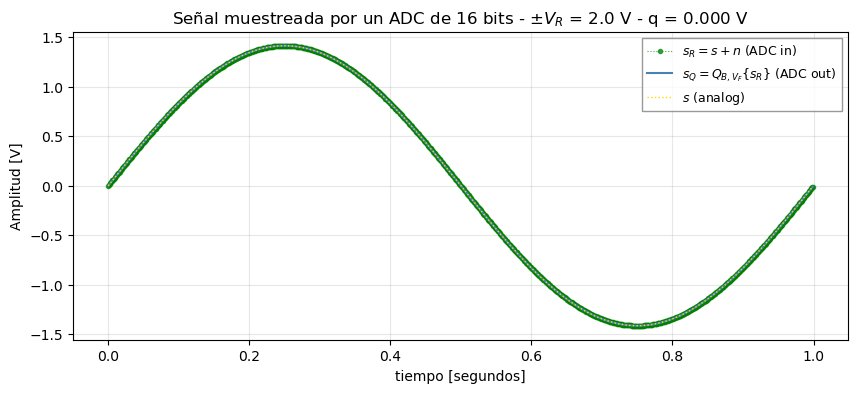

In [109]:
tt1, xx1 = mi_funcion_sen_ruido(A, dc, f0, fase, muestras, fs, snr, pr)
tt, xx = mi_funcion_sen(A, dc, f0, fase, muestras, fs)


Sr = xx1

sq = np.round(Sr / qq) * qq

plt.figure(figsize=(10, 4))
plt.plot(tt1, Sr, color='green', linewidth=0.8, linestyle=':', marker ='o', markersize=3, alpha=0.7, label=r'$s_R = s + n$ (ADC in)')
plt.plot(tt1, sq, color='steelblue', linewidth=1.5, linestyle='-', label=r'$s_Q = Q_{B,V_F}\{s_R\}$ (ADC out)')
plt.plot(tt, xx, color='gold', linewidth=1, linestyle=':', label=r'$s$ (analog)')
plt.title(f"Señal muestreada por un ADC de {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V")
plt.xlabel("tiempo [segundos]")
plt.ylabel("Amplitud [V]")
plt.grid(True, alpha=0.3)
plt.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=9)
plt.show()

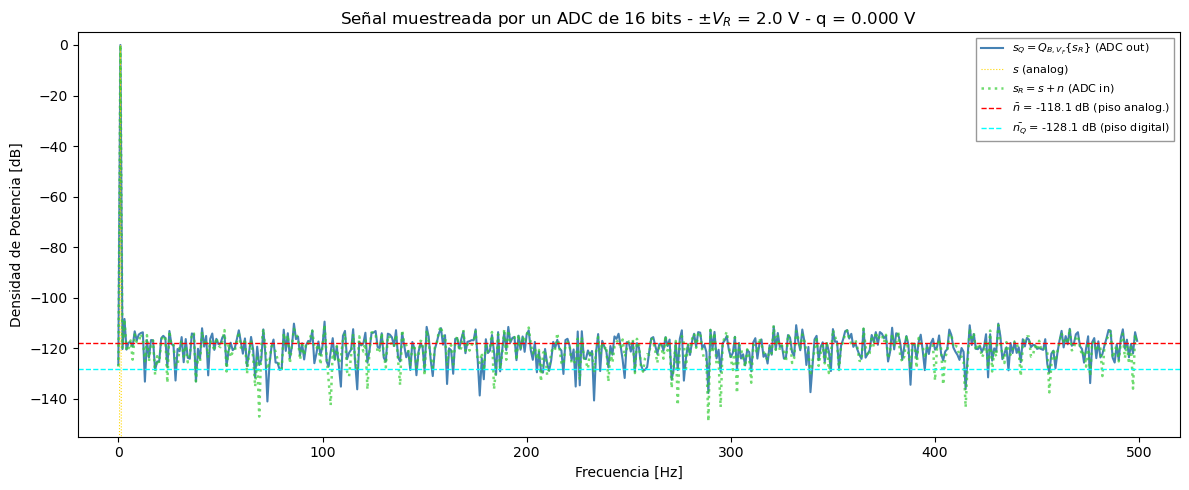

In [112]:
EspectroSr = np.fft.fft(Sr)/muestras
Mod_EspSr = 2 * (np.abs(EspectroSr))**2 

EspectroSq = np.fft.fft(sq)/muestras
Mod_EspSq = 2 * (np.abs(EspectroSq))**2 

EspectroXX = np.fft.fft(xx)/muestras
Mod_EspXX = 2 * (np.abs(EspectroXX))**2 

Sr_db = 10 * np.log10(Mod_EspSr) 
sq_db = 10 * np.log10(Mod_EspSq) 
xx_db = 10 * np.log10(Mod_EspXX)

Frec = np.fft.fftfreq(muestras, Ts)

piso_analog = 10 * np.log10(pr / (fs/2))      # densidad espectral del ruido aditivo (potencia/ancho de banda)
piso_digital = 10 * np.log10(Pq / (fs/2))     # densidad espectral del ruido de cuantización

mitad = muestras // 2
Frec_pos = Frec[:mitad]

# Espectros solo frecuencias positivas
Sr_db_pos = Sr_db[:mitad]
sq_db_pos = sq_db[:mitad]
xx_db_pos = xx_db[:mitad]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(Frec_pos, sq_db_pos, color='steelblue', linewidth=1.5, linestyle='-',
        label=r'$s_Q = Q_{B,V_F}\{s_R\}$ (ADC out)')
ax.plot(Frec_pos, xx_db_pos, color='gold', linewidth=0.8, linestyle=':',
        label=r'$s$ (analog)')
ax.plot(Frec_pos, Sr_db_pos, color='limegreen', linewidth=1.8, linestyle=':',
        markersize=2, alpha=0.7, label=r'$s_R = s + n$ (ADC in)')
ax.axhline(piso_analog,  color='red',  linestyle='--', linewidth=1,
           label=fr'$\bar{{n}}$ = {piso_analog:.1f} dB (piso analog.)')
ax.axhline(piso_digital, color='cyan', linestyle='--', linewidth=1,
           label=fr'$\bar{{n_Q}}$ = {piso_digital:.1f} dB (piso digital)')

ax.set_title(f"Señal muestreada por un ADC de {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylim([-155, 5]) 
ax.set_ylabel("Densidad de Potencia [dB]")
ax.set_xlim([-20, fs/2 + 20])
ax.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=8)

plt.tight_layout()
plt.show()

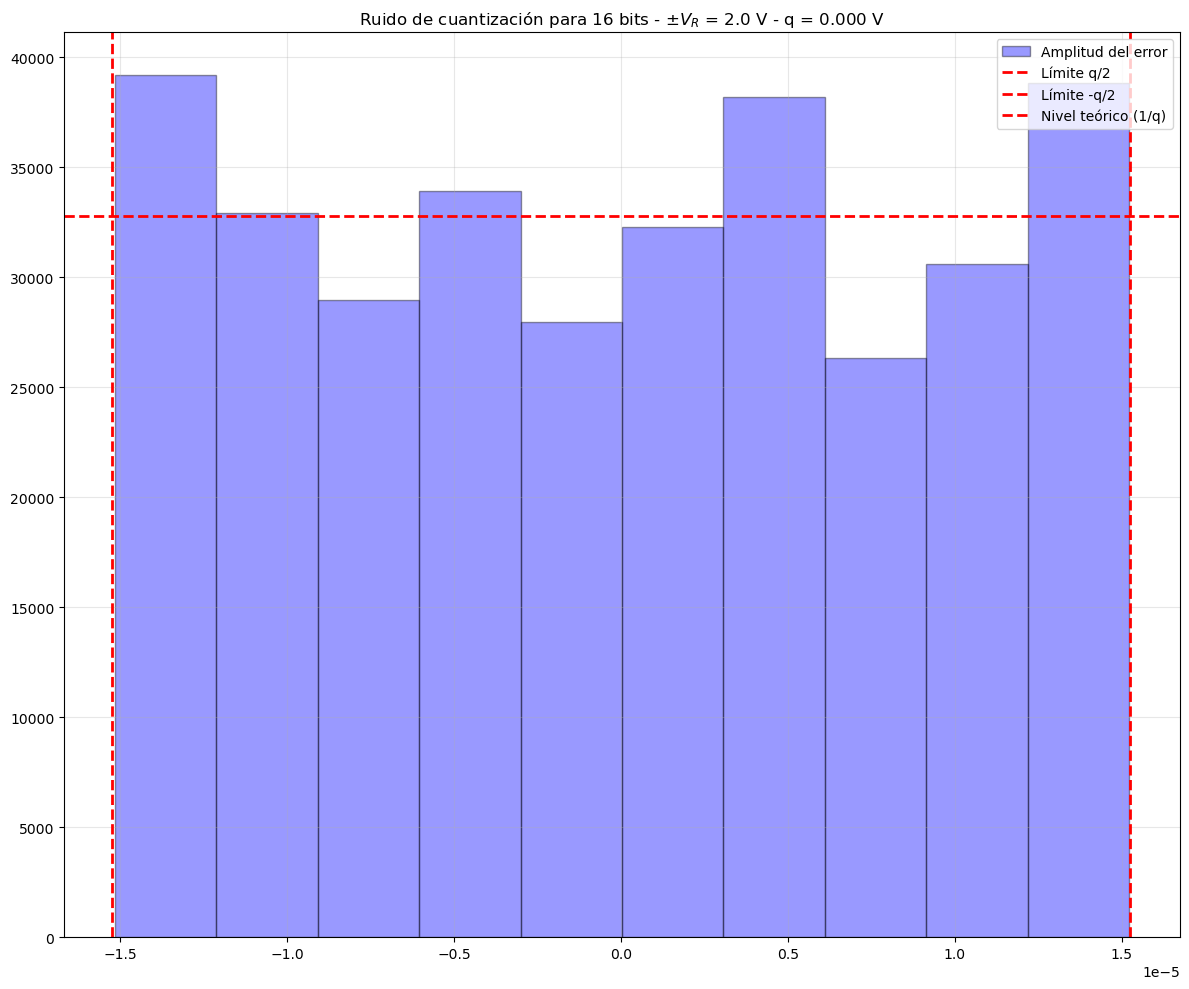

In [113]:
Eq = sq - Sr

plt.figure(figsize=(12, 10))
plt.subplot(1, 1, 1)
plt.hist(Eq, bins= 10, density=True, color='blue', alpha=0.4, edgecolor='black', label='Amplitud del error')

# Líneas guía teóricas: el error de cuantización debe vivir entre -q/2 y q/2
plt.axvline(x=qq/2, color='red', linestyle='--', linewidth=2, label='Límite q/2')
plt.axvline(x=-qq/2, color='red', linestyle='--', linewidth=2, label='Límite -q/2')

# Valor teórico de la PDF uniforme: 1/q
plt.axhline(y=1/qq, color='red', linestyle='--', linewidth=2, label='Nivel teórico (1/q)')

plt.title(f'Ruido de cuantización para {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Conclusión

En este trabajo práctico, especialmente en el ejercicio 2, podemos llegar a múltiples conclusiones y observaciones acerca del comportamiento de las señales cuantizadas dependiendo del valor de parámetros como kn y B.

Viendo kn variable con B constante (por ejemplo, tomando las combinaciones 1, 4 y 7), vemos como en cada caso la señal cuantizada se comporta distinto respecto a la señal original:
- Con un kn pequeño (kn= 1/10), el piso digital es mayor al piso analógico, lo que implica que la calidad de mi señal cuantizada es menor que mi señal original (se puede ver en como la densidad de potencia del ruido de sq es mayor al de sr), esto lo que implica es que pierdo calidad al cuantizar la señal.
- Con un kn = 1, vemos que el piso analógico y digital son iguales (como vimos también en el ejercicio 1). Este sería un caso ideal al estar trabajando con señales puesto que la calidad de la señal cuantizada que elijo es igual a la de mi señal originl, por lo que no pierdo información ni calidad.
- Por último, con un kn grande (kn = 10), vemos que el piso analógico es mayor al piso digital. Esto lo que implica es que la señal original tiene mucho ruido en comparación a la calidad de cuantización, lo que implica que al cuantizar, los bits menos significativos terminan tomando el ruido de la señal, cuantizando entonces también el ruido. Se puede observar además en el gráfico como la señal cuantizada no está acorde al piso de cuantización calculado, lo que se debe a que al ser la señal original una con mucho ruido, indefectiblemente la señal cuantizada tendrá el mismo piso de ruido (no podemos obtener de una señal digital con mucho ruido una señal analógica más limpia).

Por otro lado, viendo a B variable y kn constante (por ejemplo, comando las combinaciones 1, 2 y 3), vemos como la diferencia entre los pisos de ruido se mantienen constantes. Lo que vemos que varía es los pasos de cuantización (mi qq), donde observando el primer gráfico de las tres combinaciones vemos como el escalonamiento de mi señal cuantizada se hace cada vez más preciso (más parecido a la señal original).
También podemos observar como en el segundo gráfico la potencia de ambas señales disminuye mucho conforme sube la cantidad de bits. Esto es debido a que al estar mi pr directamente relacionada con mi pq, cuando aumenta B y disminuye qq, ambas potencias disminuyen. 

## Bonus 1: Encontrar la relación entre la cantidad de B bits del ADC y el SNR de la señal digitalizada.

Para encontrar la relacion entre el SNR de una señal digitalizada (SQNR) y la cantidad de bits (B), calculamos:

                                                                Pq = q**2/12

Sabiendo que q = Vfs/2**B

                                                            Pq = (Vfs/2**B)**2/12

Sabemos además que Vfs es la diferencia de voltaje (Vmax - Vmin) por lo que Vfs = 2 * A

                                                    Pq = (2*A/2**B)**2/12 = A**2/(3*2**2B)
Por otro lado, Px = A**2/2

Teniendo estos dos datos, planteamos a SQNR = Px/Pq

                                            SQNR = (A**2/2) / ((2*A/2**B)**2/12 = A**2/(3*2**2B))
                                                                SQNR = 3/2 * 2**2B

Podemos plantearlo en dB como SQNR(dB) = 10 * log(SQNR) = 1.76 + 6.02 * B

## Bonus 2: Simular el efecto del aliasing junto con el muestreo.

El aliasing es un fenómeno donde al muestrear una señal a una frecuencia insuficiente (fs/2 < f0), las frecuencias altas se disfrazan de bajas, resultando en distorsión o información incorrecta. Visualmente implica que observo mi señal a una frecuencia que es incorrecta.

Hagamos un ejemplo para observarlo:

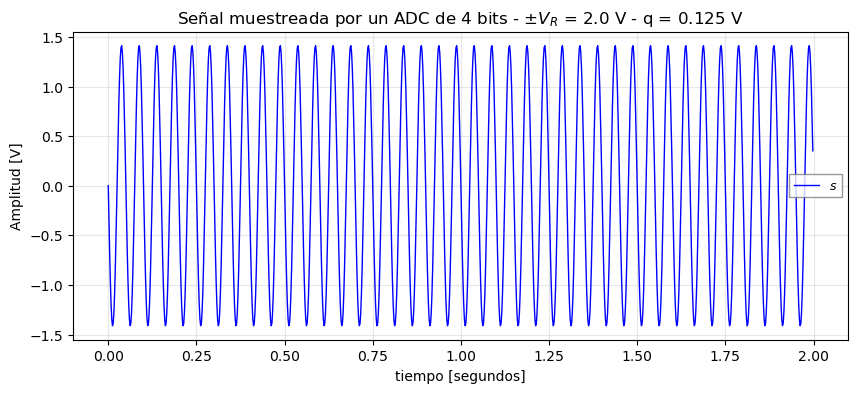

In [131]:
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1/fs
    # Usamos np.arange(nn) para asegurar exactamente 'nn' muestras
    tt = np.arange(0, nn) * ts 
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx

A = np.sqrt(2)
dc = 0
fs = 500
Ts= 1/fs
fase = 0
muestras = 1000
f0 = 480
Ps = (A**2)/ 2 

tt1, xx1 = mi_funcion_sen(A, dc, f0, fase, muestras, fs)

plt.figure(figsize=(10, 4))
plt.plot(tt1, xx1, color='blue', linewidth=1, linestyle='-', label=r'$s$')
plt.title(f"Señal muestreada por un ADC de {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V")
plt.xlabel("tiempo [segundos]")
plt.ylabel("Amplitud [V]")
plt.grid(True, alpha=0.3)
plt.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=9)
plt.show()

Como podemos ver al graficar la señal, al utilizar una frecuencia mucho mayor a nyquist (fs/2), vemos una señal de una frecuencia totalmente incorrecta. La cantidad de períodos vista es de |500 - 480| = 20, ya que luego de pasar nyquist las frecuencias se ven espejadas.

Para poder ver bien esto, graficamos la misma señal, pero con f0 = 20 donde veremos que aunque la frecuencia es muy diferente, en el gráfico se observan iguales.

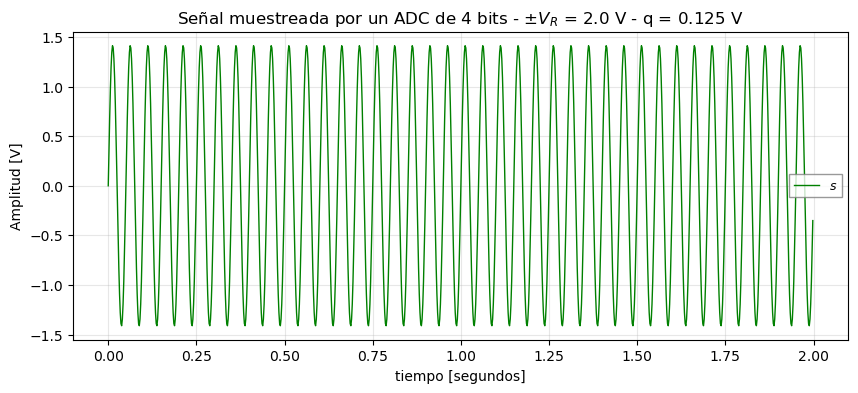

In [132]:
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1/fs
    # Usamos np.arange(nn) para asegurar exactamente 'nn' muestras
    tt = np.arange(0, nn) * ts 
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx

A = np.sqrt(2)
dc = 0
fs = 500
Ts= 1/fs
fase = 0
muestras = 1000
f0 = 20
Ps = (A**2)/ 2 

tt, xx = mi_funcion_sen(A, dc, f0, fase, muestras, fs)

plt.figure(figsize=(10, 4))
plt.plot(tt, xx, color='green', linewidth=1, linestyle='-', label=r'$s$')
plt.title(f"Señal muestreada por un ADC de {B} bits - ±$V_R$ = {Vfs:.1f} V - q = {qq:.3f} V")
plt.xlabel("tiempo [segundos]")
plt.ylabel("Amplitud [V]")
plt.grid(True, alpha=0.3)
plt.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=9)
plt.show()